In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from astropy.io import fits
import torch
import torch.nn as nn

import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset, ConcatDataset
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split, KFold
import copy
import random
import math

In [2]:
def read_unequal_table(txt_file, num_columns=383, filler=''):
    """Read table from file."""
    table = []
    with open(txt_file) as file:
        for row in file:
            values = row.split()
            if len(values) > num_columns:
                raise ValueError('Number of values more than num_columns')
            elif len(values) < num_columns:
                diff = num_columns - len(values)
                padding = [filler]*diff
                values = values + padding
            else:
                pass
            table.append(values)
    return np.array(table)

In [3]:
def read_norm_spectra(txt_file):
    """Read the saved set of normalized spectra"""
    alldata = read_unequal_table(txt_file)
    srcids = alldata[:, 0].astype(str)
    normed_spectra = alldata[:, 1:-2].astype(float)
    netcounts = alldata[:, -2].astype(float)
    src_class = alldata[:, -1].astype(str)
    return srcids, normed_spectra, netcounts, src_class

In [4]:
def refine_labels(label_array):
    """Refine labels to 4 classes."""
    refined_labels = np.full(len(label_array), '', dtype='<U16')
    for i, label in enumerate(label_array):
        if label == '':
            continue
        if label == 'AGN' or label == 'CV':
            refined_labels[i] = label
        elif label == 'LM-STAR' or label == 'HM-STAR' or label == 'YSO':
            refined_labels[i] = 'STAR'
        else:
            refined_labels[i] = 'NS/BH'
    return refined_labels

In [6]:
pn_srcids, pn_normspec, pn_counts, pn_class = read_norm_spectra('../Data/Brightmos_id_normspec_counts_label.txt')

In [7]:
pn_class_refined = refine_labels(pn_class)

In [8]:
np.unique(pn_class_refined)

array(['', 'AGN', 'CV', 'NS/BH', 'STAR'], dtype='<U16')

In [9]:
def check_spectra(normspec, refinedclass):
    """Check the normalized spectra of different classes."""
    en_bins = np.linspace(0.5, 10, len(normspec[0]))
    classes_unique = np.unique(refinedclass)
    plt.figure(figsize=(20, 12))
    plt.xlabel('Energy [keV]')
    plt.ylabel('Normalized counts [/bin]')
    plt.xscale('log')
    plt.xlim(0.5, 10.0)
    for classes in classes_unique:
        if classes != '':
            plt.plot(en_bins,
                     np.mean(normspec[refinedclass == classes], axis=0), label=classes)
    plt.legend()
    plt.show

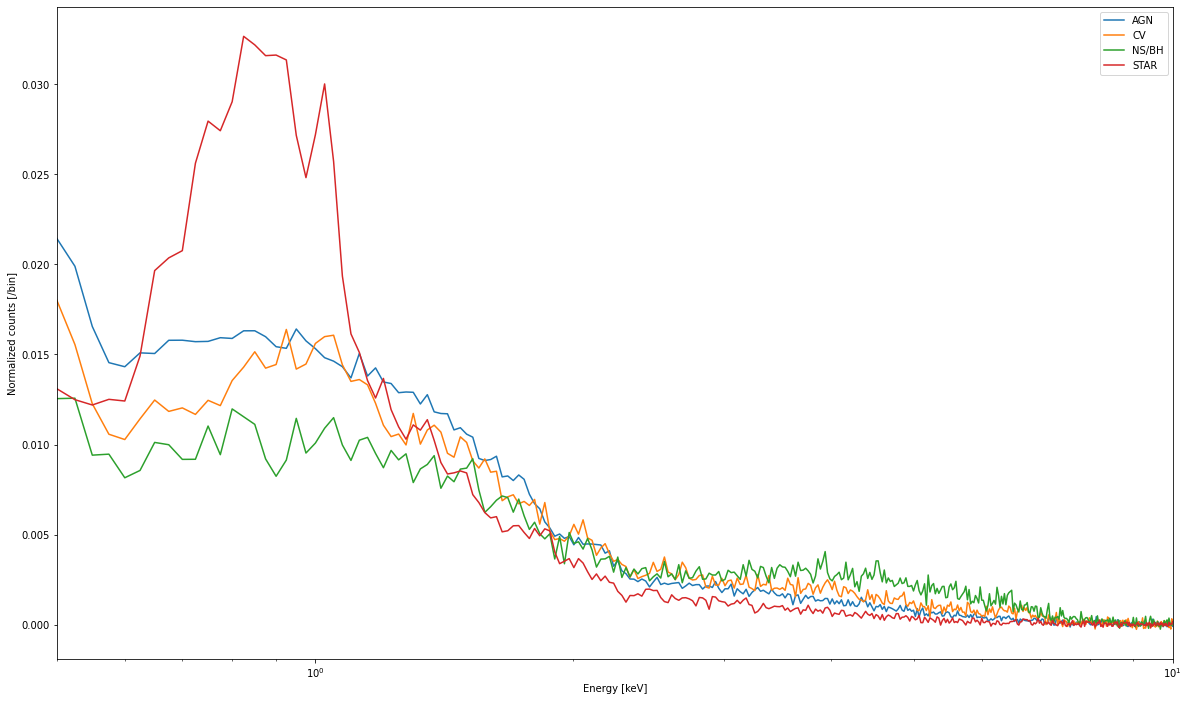

In [10]:
check_spectra(pn_normspec, pn_class_refined)

In [11]:
print(f"Number of AGN: {len(np.where(pn_class_refined == 'AGN')[0])}")
print(f"Number of STAR: {len(np.where(pn_class_refined == 'STAR')[0])}")
print(f"Number of NS: {len(np.where(pn_class_refined == 'NS/BH')[0])}")
print(f"Number of CVs: {len(np.where(pn_class_refined == 'CV')[0])}")

Number of AGN: 720
Number of STAR: 621
Number of NS: 81
Number of CVs: 81


## Baseline model for stars and AGN

In [12]:
labelled_args = np.where(np.logical_or(pn_class_refined == 'STAR',
                                       pn_class_refined == 'AGN'))
print(len(labelled_args[0]))

1341


In [13]:
unlabelled_args = np.where(pn_class_refined == '')
print(len(unlabelled_args[0]))

26523


In [14]:
print(len(labelled_args[0])+len(unlabelled_args[0]))

27864


In [15]:
pn_normspec_labelled = pn_normspec[labelled_args]
pn_spec_labels = np.zeros(len(labelled_args[0]), dtype=int)
for i, label in enumerate(pn_class_refined[labelled_args]):
    if label == 'STAR':
        pn_spec_labels[i] = 1

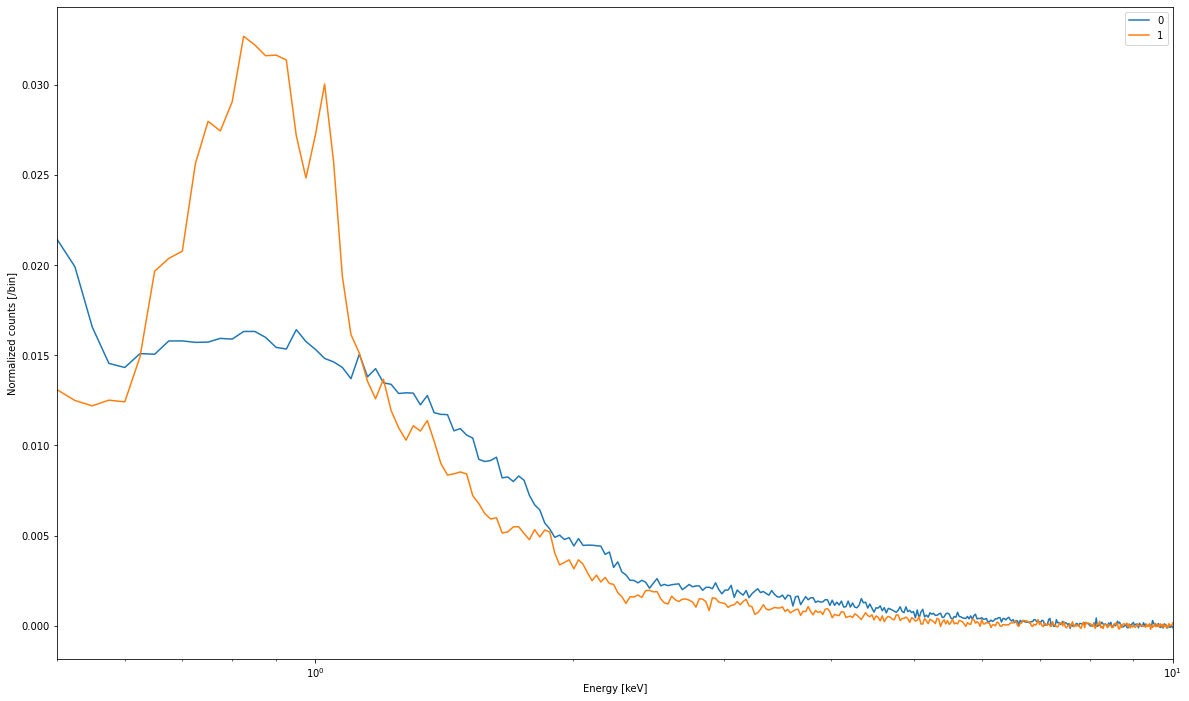

In [16]:
check_spectra(pn_normspec_labelled, pn_spec_labels)

In [30]:
def get_tensor_datasets(labelled_normspec, labels, unlabelled_normspecs,
                        train_idx=None, test_idx=None):
    """Get tensor datasets"""
    unlabelled_dataset = TensorDataset(torch.tensor(
        unlabelled_normspecs, dtype=torch.float32).unsqueeze(1))
    label_spectra_tensor = torch.tensor(labelled_normspec,
                                        dtype=torch.float32).unsqueeze(1)
    class_tensor = torch.tensor(labels, dtype=torch.long)
    labelled_dataset = TensorDataset(label_spectra_tensor, class_tensor)
    
    #Train-test split
    if train_idx is None and test_idx is None:
        train_idx, test_idx = train_test_split(np.arange(len(labels)),
                                               test_size=0.2,
                                               stratify=labels,
                                               random_state=32)

    train_ds = Subset(labelled_dataset, train_idx.astype(int))
    test_ds = Subset(labelled_dataset, test_idx.astype(int))
    return unlabelled_dataset, train_ds, test_ds

In [31]:
pn_labelled_trainids = np.loadtxt('Train_MOS_indices_foragnstars.txt')
pn_labelled_testids = np.loadtxt('Test_MOS_indices_foragnstars.txt')

In [35]:
unlabelled_specdata, train_data, test_data = get_tensor_datasets(
    pn_normspec_labelled, pn_spec_labels, pn_normspec[unlabelled_args],
    train_idx=pn_labelled_trainids, test_idx=pn_labelled_testids)

In [36]:
len(train_data)

1071

In [37]:



class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.2):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=8, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(8)
        self.pool1 = nn.MaxPool1d(2)  # 380 → 190
        self.drop1 = nn.Dropout(dropout_rate)  # <-- dropout after first conv block

        self.conv2 = nn.Conv1d(8, 16, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(16)
        self.pool2 = nn.MaxPool1d(2)  # 190 → 95
        self.drop2 = nn.Dropout(dropout_rate)  # <-- dropout after second conv block

        # final feature size = 16 * 95 = 1520
        self.fc1 = nn.Linear(16 * 95, 64)
        self.drop3 = nn.Dropout(dropout_rate)  # <-- dropout before final layer
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.drop1(x)
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.drop2(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.drop3(x)
        return self.fc2(x)

    
class ComplexCNN(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.2):
        super(ComplexCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=8, kernel_size=11, padding=5)
        self.bn1 = nn.BatchNorm1d(8)
        self.pool1 = nn.MaxPool1d(2)  # 380 → 190
        self.drop1 = nn.Dropout(dropout_rate)  # <-- dropout after first conv block

        self.conv2 = nn.Conv1d(8, 16, kernel_size=7, padding=3)
        self.bn2 = nn.BatchNorm1d(16)
        self.pool2 = nn.MaxPool1d(2)  # 190 → 95
        self.drop2 = nn.Dropout(dropout_rate)  # <-- dropout after second conv block
        
        self.conv3 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm1d(32)
        self.pool3 = nn.MaxPool1d(2)  # 95 → 47
        self.drop3 = nn.Dropout(dropout_rate)  # <-- dropout after second conv block

        # final feature size = 16 * 95 = 1520
        self.fc1 = nn.Linear(32 * 47, 512)
        self.drop4 = nn.Dropout(dropout_rate)  # <-- dropout before final layer
        self.fc2 = nn.Linear(512, 128)
        self.drop5 = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(128, 64)
        self.drop6 = nn.Dropout(dropout_rate)
        self.fc4 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.drop1(x)
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.drop2(x)
        x = self.pool3(torch.relu(self.bn3(self.conv3(x))))
        x = self.drop3(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.drop4(x)
        x = torch.relu(self.fc2(x))
        x = self.drop5(x)
        x = torch.relu(self.fc3(x))
        x = self.drop6(x)
        return self.fc4(x)

    
class OverfitNet1D(nn.Module):
    """
    Very large 1D CNN → large FC network intended to overfit small datasets.
    Remove dropout / strong regularization to encourage memorization.
    """
    def __init__(self, in_channels=1, num_classes=2, dropout_rate=0.0):
        super().__init__()
        # Deep conv tower (many channels)
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels, 128, kernel_size=15, padding=7),
            nn.ReLU(inplace=True),
            nn.Conv1d(128, 128, kernel_size=15, padding=7),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(4),

            nn.Conv1d(128, 256, kernel_size=11, padding=5),
            nn.ReLU(inplace=True),
            nn.Conv1d(256, 256, kernel_size=11, padding=5),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(4),

            nn.Conv1d(256, 512, kernel_size=7, padding=3),
            nn.ReLU(inplace=True),
            nn.Conv1d(512, 512, kernel_size=7, padding=3),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),

            nn.Conv1d(512, 1024, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv1d(1024, 1024, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1)   # collapse temporal dimension
        )
        # Huge fully-connected head
        self.fc = nn.Sequential(
            nn.Linear(1024, 4096),
            nn.ReLU(inplace=True),
            # intentionally NO dropout
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        # x: (batch, channels, length)
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)  # (batch, 1024)
        x = self.fc(x)
        return x


def l1_penalty(model):
    l1_norm = sum(p.abs().sum() for p in model.parameters())
    return l1_norm


def make_model(model_type=SimpleCNN, numclass=2, drop_rate=0.0):
    return model_type(num_classes=numclass, dropout_rate=drop_rate)

In [20]:
class CNN1D(nn.Module):
    """
    Improved 1D CNN with deeper architecture for better feature extraction.
    Uses 3 conv layers, wider channels, and dropout for regularization.
    """
    def __init__(self, num_classes: int = 2, dropout_rate: float = 0.5):
        super().__init__()
        self.features = nn.Sequential(
            # Layer 1: 1 -> 64 channels
            nn.Conv1d(1, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
            
            # Layer 2: 64 -> 128 channels
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),
            
            # Layer 3: 128 -> 256 channels
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),
            
            nn.AdaptiveAvgPool1d(1),  # -> (N, 256, 1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),             # -> (N, 256)
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.6),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [19]:
make_model(ComplexCNN, 2, 0.0)

ComplexCNN(
  (conv1): Conv1d(1, 8, kernel_size=(11,), stride=(1,), padding=(5,))
  (bn1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.0, inplace=False)
  (conv2): Conv1d(8, 16, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.0, inplace=False)
  (conv3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop3): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=1504, out_features=512, bias=True)
  (drop4): Dropout(p=0.0, inplace=False)
  (fc2): Linear(in_feature

In [20]:
make_model(SimpleCNN, 2, 0.2)

SimpleCNN(
  (conv1): Conv1d(1, 8, kernel_size=(11,), stride=(1,), padding=(5,))
  (bn1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.2, inplace=False)
  (conv2): Conv1d(8, 16, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=1520, out_features=64, bias=True)
  (drop3): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

In [22]:
# -----------------------
# 2. Training function
# -----------------------
def evaluate(model, loader, device, loss_cr):
    model.eval()
    correct, total = 0, 0
    tot_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            outs = model(xb)
            loss = loss_cr(outs, yb).item()
            preds = outs.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
            tot_loss += loss*yb.size(0)
    return correct / total, tot_loss/total


def get_batch_loss(model, inputs_l, labels_l, model_opt, loss_cr,
                   inputs_ul=None, pseudo_labels_ul=None, mask=None,
                   l1_lam=0.0, lam_u=0.0, soft_labels=None):
    """Train one batch of the model. Pseudolabel option available.

    Assuming the inputs and labels have already been cast onto device
    If you want to use soft labels, pass prob_ul instead of pseudo_labsl
    """
    outputs_l = model(inputs_l)
    loss_l = loss_cr(outputs_l, labels_l) # Supervised loss

    # For accuracy
    pred_l = torch.max(outputs_l, 1)[1]
    total_l = labels_l.size(0)
    correct_l = (pred_l == labels_l).sum().item()
    
    if inputs_ul is not None and mask is not None and mask.sum() > 0:
        outputs_ul = model(inputs_ul[mask])
        # Get unsupervised accuracy
        pred_ul = torch.max(outputs_ul, 1)[1]
        total_ul = mask.sum()
        correct_ul = (pred_ul == pseudo_labels_ul[mask]).sum().item()
        batch_ul_acc = correct_ul/total_ul
        
        # Get unsupervised loss
        if lam_u > 0:
            if soft_labels is not None:
                # Soft labels
                loss_ul = nn.functional.kl_div(
                    nn.functional.log_softmax(outputs_ul, dim=1),
                    soft_labels[mask], reduction='batchmean')
            else:
                loss_ul = loss_cr(outputs_ul, pseudo_labels_ul[mask])
        else:
            loss_ul = 0
    else:
        batch_ul_acc = None
        loss_ul = 0
    
    if l1_lam > 0:
        l1_loss = l1_lam*l1_penalty(model) # L1 reg.
    else:
        l1_loss = 0
    
    batch_loss = loss_l + lam_u*loss_ul + l1_loss
    # print(f'Supervised Loss:{loss_l} | Unsupervised Loss:{loss_ul} | Batch loss: {batch_loss}')
    
    return batch_loss, correct_l/total_l, batch_ul_acc


def train_one_batch(model, prev_batch_loss, inputs_l, labels_l, model_opt, 
                    loss_cr, inputs_ul=None, l1_lam=0.0, lam_u=0.0,
                    thresh=0.95, use_softlabels=False):
    """Train model by one epoch.
    
    Batch loss from the previous batch, not the current batch.
    """
    # First get pseudo labels from the model before updating the weights
    pseudolabels_ul, probs_ul, mask = None, None, None
    if inputs_ul is not None:
        with torch.no_grad():
            probs_ul = torch.softmax(model(inputs_ul), dim=1)
            conf_ul, pseudolabels_ul = torch.max(probs_ul, dim=1)
            mask = (conf_ul > thresh)
            soft_labels = probs_ul if use_softlabels else None

    else:
        soft_labels = None
    
    
    if prev_batch_loss is not None:
        # If previous batch loss is None, don't update anything and
        # don't calculate unsupervised loss, else
        # Update model weights
        model_opt.zero_grad()
        prev_batch_loss.backward()
        model_opt.step()
        # clear memory
        del prev_batch_loss
        torch.cuda.empty_cache()
    else:
        inputs_ul = None
    
    # Calculate batch loss accuracy for current batch using pseudolabels before
    # updating the weights
    
    # Get accuracy and loss for current batch based on labels before update
    
    batch_loss, batch_l_acc, batch_ul_acc = get_batch_loss(
        model, inputs_l, labels_l, model_opt, loss_cr,
        inputs_ul, pseudolabels_ul, mask, l1_lam, lam_u, soft_labels)
    
    return batch_loss, batch_l_acc, batch_ul_acc



def train_one_epoch(model, l_loader, model_optimizer, loss_criterion, device,
                    ul_loader=None, l1_lambda=0.0, lambda_u=0.0,
                    threshold=0.95, prev_loss=None,
                    update_last_model=None):
    """Train one epoch of the ML model

    If prev_loss is given, it's assumed that the model hasn't been updated yet
    """
    model.train()
    total_loss, runacc_l, runacc_ul = 0.0, 0.0, 0.0  # , 0.0
    num_labeled_batches = len(l_loader)
    num_unlabeled_batches = len(ul_loader) if ul_loader is not None else 0

    # Making lists for random access if needed
    labeled_batches = list(l_loader)
    unlabeled_batches = list(ul_loader) if ul_loader is not None else []
    if ul_loader is not None:
        random.shuffle(unlabeled_batches)
    
    used_unlabeled = 0
    num_ulbatches = 0

    for numbatch, (inputs_l, labels_l) in enumerate(l_loader):
        inputs_l, labels_l = inputs_l.to(device), labels_l.to(device)
        # Fetch unlabeled data
        if ul_loader is not None:
            if used_unlabeled < num_unlabeled_batches:
                ul_batch = unlabeled_batches[used_unlabeled]
                if isinstance(ul_batch, (tuple, list)):
                    inputs_ul = ul_batch[0].to(device)
                else:
                    inputs_ul = ul_batch.to(device)
                used_unlabeled += 1
            else:
                ul_batch = random.choice(unlabeled_batches)
                if isinstance(ul_batch, (tuple, list)):
                    inputs_ul = ul_batch[0].to(device)
                else:
                    inputs_ul = ul_batch.to(device)
        else:
            inputs_ul=None

        if prev_loss is not None:
            # If the loss and model are from previous step i.e. weights not yet
            # updated
            batch_loss, batch_acc_l, batch_acc_u = train_one_batch(
                model, prev_loss, inputs_l, labels_l, model_optimizer,
                loss_criterion, inputs_ul=inputs_ul, l1_lam=l1_lambda,
                lam_u=lambda_u, thresh=threshold)
            del prev_loss
            torch.cuda.empty_cache()
        else:
            # If prev loss not given and model weights are already updated,
            # e.g. in the first batch of first epoch, calculate supervised loss
            # only
            print('No prev loss')
            batch_loss, batch_acc_l, batch_acc_u = train_one_batch(
                model, prev_loss,
                inputs_l, labels_l, model_optimizer, loss_criterion,
                inputs_ul=None)
            
        prev_loss = batch_loss

        total_loss += batch_loss.item()
        runacc_l = (runacc_l*numbatch + batch_acc_l)/(numbatch + 1)
        if batch_acc_u is not None:
            runacc_ul = (
                runacc_ul*num_ulbatches + batch_acc_u)/(num_ulbatches + 1)
            num_ulbatches += 1

    # If unlabelled data remain
    while used_unlabeled < num_unlabeled_batches:
        ul_batch = unlabeled_batches[used_unlabeled]
        if isinstance(ul_batch, (tuple, list)):
            inputs_ul = ul_batch[0].to(device)
        else:
            inputs_ul = ul_batch.to(device)
        used_unlabeled += 1
        inputs_l, labels_l = random.choice(labeled_batches)
        inputs_l, labels_l = inputs_l.to(device), labels_l.to(device)

        # It's assumed that the weights haven't been updated
        batch_loss, batch_acc_l, batch_acc_u = train_one_batch(
                model, prev_loss, inputs_l, labels_l, model_optimizer,
                loss_criterion, inputs_ul=inputs_ul, l1_lam=l1_lambda,
                lam_u=lambda_u, thresh=threshold)
        del prev_loss
        torch.cuda.empty_cache()
        prev_loss = batch_loss

        numbatch += 1
        total_loss += batch_loss.item()
        runacc_l = (runacc_l*numbatch + batch_acc_l)/(numbatch + 1)
        if batch_acc_u is not None:
            runacc_ul = (
                runacc_ul*num_ulbatches + batch_acc_u)/(num_ulbatches + 1)
            num_ulbatches += 1
    
    # acc_l = evaluate(model, loader, device)
    avg_loss = total_loss/(numbatch+1)
    if update_last_model:
        model_optimizer.zero_grad()
        prev_loss.backward()
        model_optimizer.step()
    return model, avg_loss, runacc_l, runacc_ul, prev_loss


def train_model(base_model, full_train_dataset, test_dataset,
                unlabeled_dataset=None, epochs=20, batch_size=32,
                unlabeled_batch_size=64, k_folds=5, l1_lambda=0.0,
                l2_lambda=1.0e-4, droprate=0.2, numclasses=2, threshold=0.95,
                model_class=None, base_model_is_fn=True, op_alg='Adam',
                verbose=1, lambda_u_func=None):
    """Train model. If unlabeled data is provider use Lee (2013)"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    kfold = KFold(n_splits=k_folds, shuffle=True)
    if model_class is None and base_model_is_fn:
        model_class = SimpleCNN

    val_acc_per_fold = []
    models = []

    for fold, (train_idx, val_idx) in enumerate(
                                        kfold.split(full_train_dataset)):
        print(f"\n--- Fold {fold+1}/{k_folds} ---")
        train_subset = torch.utils.data.Subset(full_train_dataset, train_idx)
        val_subset = torch.utils.data.Subset(full_train_dataset, val_idx)

        # Load Datasets
        train_loader = DataLoader(train_subset, batch_size=batch_size,
                                  shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=batch_size,
                                shuffle=False)
        if unlabeled_dataset is not None:
            unlabeled_loader = DataLoader(
                unlabeled_dataset, batch_size=unlabeled_batch_size,
                shuffle=True)
        else:
            unlabeled_loader=None

        # Set up model, optimizer and loss
        if base_model_is_fn:
            model = base_model(model_class, numclasses, droprate).to(device)
        else:
            model = copy.deepcopy(base_model)
        if op_alg == 'Adam':
            optimizer = optim.Adam(model.parameters(), lr=1e-3,
                                   weight_decay=l2_lambda)
        elif op_alg == 'SGD':
            optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9,
                                  weight_decay=l2_lambda, nesterov=True)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.25, patience=5, min_lr=1e-6)
        criterion = nn.CrossEntropyLoss()

        prev_epochloss = None
        update_last_model = False
        
        for epoch in range(epochs):
            if epoch == epochs - 1:
                update_last_model = True
            if lambda_u_func is None:
                if epoch < 2:
                    lambda_u = 0
                else:
                    lambda_u = min(3.0, 0.2 + 3*(epoch - 1) / (epochs*0.8))
    
            else:
                lambda_u = lambda_u_func(epoch, epochs)

            #threshold_new = min(threshold,
            #                    (0.70 - (0.70-threshold)*epoch/(epochs*0.5)))
            (model, avg_loss, acc_train_l, acc_train_ul,
             epoch_loss) = train_one_epoch(
                model, train_loader, optimizer, criterion, device,
                ul_loader=unlabeled_loader, l1_lambda=l1_lambda,
                lambda_u=lambda_u, threshold=threshold,
                prev_loss=prev_epochloss, update_last_model=update_last_model)
            val_acc, val_loss = evaluate(model, val_loader, device, criterion)
            
            old_lr = optimizer.param_groups[0]['lr']
            scheduler.step(val_loss)
            new_lr = optimizer.param_groups[0]['lr']
            if new_lr < old_lr:
                print(f'Learning rate changed to {new_lr:.6f}')
            
            prev_epochloss = epoch_loss
            if verbose == 1:
                print(
                    f"Epoch {epoch+1}/{epochs} | Loss={avg_loss:.4f} | "
                    f"Labeled Train Acc={acc_train_l:.4f} | "
                    f"Val Acc={val_acc:.4f} | "
                    f"Unlabeled Train Acc={acc_train_ul:.4f} | "
                    f"lambda_u:{lambda_u:.4f} | "
                    f"Threshold:{threshold}")
                print(f"Val loss:{val_loss:.4f}")

        models.append(model)
        val_acc_per_fold.append(val_acc)

    print(f"\nCross-validation results: {val_acc_per_fold}")
    print(f"Mean Val Acc: {np.mean(val_acc_per_fold):.4f} ± {np.std(val_acc_per_fold):.4f}")

    # Pick the best fold’s model
    best_model = models[np.argmax(val_acc_per_fold)]


    # Final test evaluation
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
    test_acc = evaluate(best_model, test_loader, device, criterion)[0]
    print(f"\nHold-out Test Accuracy: {test_acc:.4f}")

    return best_model
# -----------------------
# 3. Pseudo-labeling function
# -----------------------
def get_pseudo_labels(model, unlabeled_loader, threshold=0.95):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    pseudo_X, pseudo_y = [], []
    with torch.no_grad():
        for xb in unlabeled_loader:
            xb = xb[0].to(device)  # DataLoader yields a tuple
            probs = torch.softmax(model(xb), dim=1)
            conf, pred = torch.max(probs, dim=1)
            mask = conf > threshold
            pseudo_X.append(xb[mask].cpu())
            pseudo_y.append(pred[mask].cpu())
    if len(pseudo_X) == 0:
        return None
    pseudo_X = torch.cat(pseudo_X)
    pseudo_y = torch.cat(pseudo_y)
    return TensorDataset(pseudo_X, pseudo_y)



In [352]:
conf_ul2.min()

tensor(0.5001)

# Supervised training bounds

In [311]:
# No regularization
simplecnn_noreg = train_model(make_model, train_data, test_data, l2_lambda=0.0, l1_lambda=0.0, droprate=0.0, verbose=1,
                              model_class=SimpleCNN)


--- Fold 1/5 ---
No prev loss
Epoch 1/20 | Loss=0.3958 | Labeled Train Acc=0.8473 | Val Acc=0.5728 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.95
Epoch 2/20 | Loss=0.2018 | Labeled Train Acc=0.9319 | Val Acc=0.8494 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.95
Epoch 3/20 | Loss=0.1384 | Labeled Train Acc=0.9582 | Val Acc=0.8667 | Unlabeled Train Acc=0.0000 | lambda_u:0.1625 | Threshold:0.95
Epoch 4/20 | Loss=0.1133 | Labeled Train Acc=0.9638 | Val Acc=0.8988 | Unlabeled Train Acc=0.0000 | lambda_u:0.2250 | Threshold:0.95
Epoch 5/20 | Loss=0.0795 | Labeled Train Acc=0.9776 | Val Acc=0.9037 | Unlabeled Train Acc=0.0000 | lambda_u:0.2875 | Threshold:0.95
Epoch 6/20 | Loss=0.0574 | Labeled Train Acc=0.9849 | Val Acc=0.8938 | Unlabeled Train Acc=0.0000 | lambda_u:0.3500 | Threshold:0.95
Epoch 7/20 | Loss=0.0533 | Labeled Train Acc=0.9843 | Val Acc=0.8914 | Unlabeled Train Acc=0.0000 | lambda_u:0.4125 | Threshold:0.95
Epoch 8/20 | Loss=0.0344 | Labeled Tra

Epoch 2/20 | Loss=0.2395 | Labeled Train Acc=0.9174 | Val Acc=0.9235 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.95
Epoch 3/20 | Loss=0.1597 | Labeled Train Acc=0.9449 | Val Acc=0.9407 | Unlabeled Train Acc=0.0000 | lambda_u:0.1625 | Threshold:0.95
Epoch 4/20 | Loss=0.1226 | Labeled Train Acc=0.9620 | Val Acc=0.9457 | Unlabeled Train Acc=0.0000 | lambda_u:0.2250 | Threshold:0.95
Epoch 5/20 | Loss=0.0996 | Labeled Train Acc=0.9700 | Val Acc=0.9457 | Unlabeled Train Acc=0.0000 | lambda_u:0.2875 | Threshold:0.95
Epoch 6/20 | Loss=0.0800 | Labeled Train Acc=0.9756 | Val Acc=0.9284 | Unlabeled Train Acc=0.0000 | lambda_u:0.3500 | Threshold:0.95
Epoch 7/20 | Loss=0.0604 | Labeled Train Acc=0.9843 | Val Acc=0.9481 | Unlabeled Train Acc=0.0000 | lambda_u:0.4125 | Threshold:0.95
Epoch 8/20 | Loss=0.0457 | Labeled Train Acc=0.9898 | Val Acc=0.9457 | Unlabeled Train Acc=0.0000 | lambda_u:0.4750 | Threshold:0.95
Epoch 9/20 | Loss=0.0340 | Labeled Train Acc=0.9939 | Val Acc=0.9506 

In [23]:
# Add regularization
simplecnn_withreg = train_model(make_model, train_data, test_data, l2_lambda=1.0e-4, l1_lambda=1.0e-5, droprate=0.0, verbose=1,
                             model_class=SimpleCNN)


--- Fold 1/5 ---
No prev loss
Epoch 1/20 | Loss=0.4989 | Labeled Train Acc=0.7803 | Val Acc=0.4930 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.95
Val loss:0.8180
Epoch 2/20 | Loss=0.2756 | Labeled Train Acc=0.8967 | Val Acc=0.4930 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.95
Val loss:0.7461
Epoch 3/20 | Loss=0.1594 | Labeled Train Acc=0.9430 | Val Acc=0.8000 | Unlabeled Train Acc=0.0000 | lambda_u:0.3875 | Threshold:0.95
Val loss:0.4487
Epoch 4/20 | Loss=0.1037 | Labeled Train Acc=0.9785 | Val Acc=0.5163 | Unlabeled Train Acc=0.0000 | lambda_u:0.5750 | Threshold:0.95
Val loss:1.9382
Epoch 5/20 | Loss=0.0684 | Labeled Train Acc=0.9873 | Val Acc=0.5116 | Unlabeled Train Acc=0.0000 | lambda_u:0.7625 | Threshold:0.95
Val loss:2.7612
Epoch 6/20 | Loss=0.0450 | Labeled Train Acc=0.9977 | Val Acc=0.6419 | Unlabeled Train Acc=0.0000 | lambda_u:0.9500 | Threshold:0.95
Val loss:1.1753
Epoch 7/20 | Loss=0.0381 | Labeled Train Acc=0.9977 | Val Acc=0.8558 | Unla

Learning rate changed to 0.000063
Epoch 15/20 | Loss=0.0202 | Labeled Train Acc=1.0000 | Val Acc=0.7056 | Unlabeled Train Acc=0.0000 | lambda_u:2.6375 | Threshold:0.95
Val loss:1.0227
Epoch 16/20 | Loss=0.0200 | Labeled Train Acc=1.0000 | Val Acc=0.9159 | Unlabeled Train Acc=0.0000 | lambda_u:2.8250 | Threshold:0.95
Val loss:0.2818
Epoch 17/20 | Loss=0.0205 | Labeled Train Acc=1.0000 | Val Acc=0.9252 | Unlabeled Train Acc=0.0000 | lambda_u:3.0000 | Threshold:0.95
Val loss:0.2805
Epoch 18/20 | Loss=0.0200 | Labeled Train Acc=1.0000 | Val Acc=0.9206 | Unlabeled Train Acc=0.0000 | lambda_u:3.0000 | Threshold:0.95
Val loss:0.2749
Epoch 19/20 | Loss=0.0193 | Labeled Train Acc=1.0000 | Val Acc=0.9206 | Unlabeled Train Acc=0.0000 | lambda_u:3.0000 | Threshold:0.95
Val loss:0.2684
Epoch 20/20 | Loss=0.0195 | Labeled Train Acc=1.0000 | Val Acc=0.9206 | Unlabeled Train Acc=0.0000 | lambda_u:3.0000 | Threshold:0.95
Val loss:0.2792

--- Fold 4/5 ---
No prev loss
Epoch 1/20 | Loss=0.5465 | Labeled 

In [27]:
torch.save(simplecnn_withreg, 'SimpleCNN_withreg_MOS.pt')

In [38]:
# No regularization
overfitcnn_noreg = train_model(make_model, train_data, test_data, l2_lambda=0.0, l1_lambda=0.0, droprate=0.0, verbose=1,
                               model_class=CNN1D)


--- Fold 1/5 ---
No prev loss
Epoch 1/20 | Loss=0.6764 | Labeled Train Acc=0.6034 | Val Acc=0.5210 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.7
Epoch 2/20 | Loss=0.6287 | Labeled Train Acc=0.7446 | Val Acc=0.7753 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.725
Epoch 3/20 | Loss=0.5626 | Labeled Train Acc=0.7770 | Val Acc=0.8000 | Unlabeled Train Acc=0.0000 | lambda_u:0.3875 | Threshold:0.75
Epoch 4/20 | Loss=0.5090 | Labeled Train Acc=0.8069 | Val Acc=0.8000 | Unlabeled Train Acc=0.0000 | lambda_u:0.5750 | Threshold:0.7749999999999999
Epoch 5/20 | Loss=0.4937 | Labeled Train Acc=0.8114 | Val Acc=0.8123 | Unlabeled Train Acc=0.0000 | lambda_u:0.7625 | Threshold:0.7999999999999999
Epoch 6/20 | Loss=0.4741 | Labeled Train Acc=0.8104 | Val Acc=0.8173 | Unlabeled Train Acc=0.0000 | lambda_u:0.9500 | Threshold:0.825
Epoch 7/20 | Loss=0.4476 | Labeled Train Acc=0.8315 | Val Acc=0.7827 | Unlabeled Train Acc=0.0000 | lambda_u:1.1375 | Threshold:0.85
Epoch 8/2

Epoch 1/20 | Loss=0.6777 | Labeled Train Acc=0.6074 | Val Acc=0.5160 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.7
Epoch 2/20 | Loss=0.6257 | Labeled Train Acc=0.7609 | Val Acc=0.7654 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.725
Epoch 3/20 | Loss=0.5751 | Labeled Train Acc=0.7795 | Val Acc=0.8074 | Unlabeled Train Acc=0.0000 | lambda_u:0.3875 | Threshold:0.75
Epoch 4/20 | Loss=0.5257 | Labeled Train Acc=0.8061 | Val Acc=0.8321 | Unlabeled Train Acc=0.0000 | lambda_u:0.5750 | Threshold:0.7749999999999999
Epoch 5/20 | Loss=0.5106 | Labeled Train Acc=0.8018 | Val Acc=0.8099 | Unlabeled Train Acc=0.0000 | lambda_u:0.7625 | Threshold:0.7999999999999999
Epoch 6/20 | Loss=0.4881 | Labeled Train Acc=0.8098 | Val Acc=0.8000 | Unlabeled Train Acc=0.0000 | lambda_u:0.9500 | Threshold:0.825
Epoch 7/20 | Loss=0.4743 | Labeled Train Acc=0.8192 | Val Acc=0.8049 | Unlabeled Train Acc=0.0000 | lambda_u:1.1375 | Threshold:0.85
Epoch 8/20 | Loss=0.4523 | Labeled Train

In [315]:
cnn3FC_withreg = train_model(make_model, train_data, test_data, l2_lambda=1.0e-4, l1_lambda=1.0e-5, droprate=0.1, verbose=1,
                           model_class=CNN_3FC)


--- Fold 1/5 ---
No prev loss
Epoch 1/20 | Loss=0.5150 | Labeled Train Acc=0.8130 | Val Acc=0.5457 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.95
Epoch 2/20 | Loss=0.2855 | Labeled Train Acc=0.9062 | Val Acc=0.8914 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.95
Epoch 3/20 | Loss=0.2174 | Labeled Train Acc=0.9402 | Val Acc=0.9259 | Unlabeled Train Acc=0.0000 | lambda_u:0.1625 | Threshold:0.95
Epoch 4/20 | Loss=0.1809 | Labeled Train Acc=0.9515 | Val Acc=0.9012 | Unlabeled Train Acc=0.0000 | lambda_u:0.2250 | Threshold:0.95
Epoch 5/20 | Loss=0.1696 | Labeled Train Acc=0.9555 | Val Acc=0.9111 | Unlabeled Train Acc=0.0000 | lambda_u:0.2875 | Threshold:0.95
Epoch 6/20 | Loss=0.1413 | Labeled Train Acc=0.9675 | Val Acc=0.8963 | Unlabeled Train Acc=0.0000 | lambda_u:0.3500 | Threshold:0.95
Epoch 7/20 | Loss=0.1666 | Labeled Train Acc=0.9528 | Val Acc=0.8840 | Unlabeled Train Acc=0.0000 | lambda_u:0.4125 | Threshold:0.95
Epoch 8/20 | Loss=0.1241 | Labeled Tra

Epoch 2/20 | Loss=0.3118 | Labeled Train Acc=0.8895 | Val Acc=0.9136 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.95
Epoch 3/20 | Loss=0.2449 | Labeled Train Acc=0.9207 | Val Acc=0.9235 | Unlabeled Train Acc=0.0000 | lambda_u:0.1625 | Threshold:0.95
Epoch 4/20 | Loss=0.2094 | Labeled Train Acc=0.9423 | Val Acc=0.9259 | Unlabeled Train Acc=0.0000 | lambda_u:0.2250 | Threshold:0.95
Epoch 5/20 | Loss=0.1803 | Labeled Train Acc=0.9490 | Val Acc=0.8938 | Unlabeled Train Acc=0.0000 | lambda_u:0.2875 | Threshold:0.95
Epoch 6/20 | Loss=0.1654 | Labeled Train Acc=0.9561 | Val Acc=0.9259 | Unlabeled Train Acc=0.0000 | lambda_u:0.3500 | Threshold:0.95
Epoch 7/20 | Loss=0.1518 | Labeled Train Acc=0.9589 | Val Acc=0.9086 | Unlabeled Train Acc=0.0000 | lambda_u:0.4125 | Threshold:0.95
Epoch 8/20 | Loss=0.1525 | Labeled Train Acc=0.9623 | Val Acc=0.8642 | Unlabeled Train Acc=0.0000 | lambda_u:0.4750 | Threshold:0.95
Epoch 9/20 | Loss=0.1303 | Labeled Train Acc=0.9718 | Val Acc=0.8741 

In [375]:
# Second way to train model
test_model = make_model()

test_model = train_model(test_model, train_data, test_data, l2_lambda=0.0, l1_lambda=0.0, droprate=0.0,
                         base_model_is_fn=False)


--- Fold 1/5 ---
No prev loss
Epoch 1/20 | Loss=0.3718 | Labeled Train Acc=0.8388 | Val Acc=0.5605 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.7
Epoch 2/20 | Loss=0.1758 | Labeled Train Acc=0.9406 | Val Acc=0.9210 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.725
Epoch 3/20 | Loss=0.1186 | Labeled Train Acc=0.9577 | Val Acc=0.9235 | Unlabeled Train Acc=0.0000 | lambda_u:0.3875 | Threshold:0.75
Epoch 4/20 | Loss=0.0934 | Labeled Train Acc=0.9702 | Val Acc=0.9012 | Unlabeled Train Acc=0.0000 | lambda_u:0.5750 | Threshold:0.7749999999999999
Epoch 5/20 | Loss=0.0578 | Labeled Train Acc=0.9874 | Val Acc=0.8741 | Unlabeled Train Acc=0.0000 | lambda_u:0.7625 | Threshold:0.7999999999999999
Epoch 6/20 | Loss=0.0440 | Labeled Train Acc=0.9920 | Val Acc=0.9358 | Unlabeled Train Acc=0.0000 | lambda_u:0.9500 | Threshold:0.825
Epoch 7/20 | Loss=0.0311 | Labeled Train Acc=0.9945 | Val Acc=0.9407 | Unlabeled Train Acc=0.0000 | lambda_u:1.1375 | Threshold:0.85
Epoch 8/2

Epoch 1/20 | Loss=0.3724 | Labeled Train Acc=0.8531 | Val Acc=0.6346 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.7
Epoch 2/20 | Loss=0.1817 | Labeled Train Acc=0.9368 | Val Acc=0.9333 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.725
Epoch 3/20 | Loss=0.1185 | Labeled Train Acc=0.9600 | Val Acc=0.9309 | Unlabeled Train Acc=0.0000 | lambda_u:0.3875 | Threshold:0.75
Epoch 4/20 | Loss=0.0867 | Labeled Train Acc=0.9749 | Val Acc=0.9432 | Unlabeled Train Acc=0.0000 | lambda_u:0.5750 | Threshold:0.7749999999999999
Epoch 5/20 | Loss=0.0663 | Labeled Train Acc=0.9849 | Val Acc=0.9284 | Unlabeled Train Acc=0.0000 | lambda_u:0.7625 | Threshold:0.7999999999999999
Epoch 6/20 | Loss=0.0517 | Labeled Train Acc=0.9859 | Val Acc=0.9210 | Unlabeled Train Acc=0.0000 | lambda_u:0.9500 | Threshold:0.825
Epoch 7/20 | Loss=0.0345 | Labeled Train Acc=0.9917 | Val Acc=0.9284 | Unlabeled Train Acc=0.0000 | lambda_u:1.1375 | Threshold:0.85
Epoch 8/20 | Loss=0.0240 | Labeled Train

In [134]:
# No regularization
model_noreg = train_model(make_model, train_data, test_data, l2_lambda=0.0, l1_lambda=0.0, droprate=0.5, verbose=0)


--- Fold 1/5 ---

--- Fold 2/5 ---

--- Fold 3/5 ---

--- Fold 4/5 ---

--- Fold 5/5 ---

Cross-validation results: [0.9234567901234568, 0.9185185185185185, 0.9209876543209876, 0.9259259259259259, 0.9333333333333333]
Mean Val Acc: 0.9244 ± 0.0051

Hold-out Test Accuracy: 0.8994


In [59]:
# Adding dropouts
for drop in [0.1, 0.2, 0.3, 0.4]:
    for l1 in [0.0, 1.0e-6, 1.0e-5, 1.0e-4]:
        for l2 in [1.0e-5, 5.0e-5, 1.0e-4, 2.0e-4]:
            print(f"Droprate:{drop}, L1_lambda:{l1},L2_lambda:{l2}")
            bestmodel = train_model(make_model, train_data, test_data,
                                    l2_lambda=l2, l1_lambda=l1, droprate=drop,
                                    k_folds=10, verbose=0)

Droprate:0.1, L1_lambda:0.0,L2_lambda:1e-05

--- Fold 1/10 ---

--- Fold 2/10 ---

--- Fold 3/10 ---

--- Fold 4/10 ---

--- Fold 5/10 ---

--- Fold 6/10 ---

--- Fold 7/10 ---

--- Fold 8/10 ---

--- Fold 9/10 ---

--- Fold 10/10 ---

Cross-validation results: [0.9211822660098522, 0.9211822660098522, 0.916256157635468, 0.9211822660098522, 0.9310344827586207, 0.9504950495049505, 0.9108910891089109, 0.9653465346534653, 0.9405940594059405, 0.8910891089108911]
Mean Val Acc: 0.9269 ± 0.0200

Hold-out Test Accuracy: 0.9231
Droprate:0.1, L1_lambda:0.0,L2_lambda:5e-05

--- Fold 1/10 ---

--- Fold 2/10 ---

--- Fold 3/10 ---

--- Fold 4/10 ---

--- Fold 5/10 ---

--- Fold 6/10 ---

--- Fold 7/10 ---

--- Fold 8/10 ---

--- Fold 9/10 ---

--- Fold 10/10 ---

Cross-validation results: [0.9359605911330049, 0.9261083743842364, 0.9556650246305419, 0.9310344827586207, 0.9359605911330049, 0.9207920792079208, 0.9356435643564357, 0.9207920792079208, 0.9455445544554455, 0.9356435643564357]
Mean Val Acc:


--- Fold 2/10 ---

--- Fold 3/10 ---

--- Fold 4/10 ---

--- Fold 5/10 ---

--- Fold 6/10 ---

--- Fold 7/10 ---

--- Fold 8/10 ---

--- Fold 9/10 ---

--- Fold 10/10 ---

Cross-validation results: [0.9458128078817734, 0.9359605911330049, 0.9261083743842364, 0.9310344827586207, 0.9310344827586207, 0.8811881188118812, 0.9158415841584159, 0.9455445544554455, 0.9207920792079208, 0.9306930693069307]
Mean Val Acc: 0.9264 ± 0.0176

Hold-out Test Accuracy: 0.9290
Droprate:0.2, L1_lambda:0.0,L2_lambda:5e-05

--- Fold 1/10 ---

--- Fold 2/10 ---

--- Fold 3/10 ---

--- Fold 4/10 ---

--- Fold 5/10 ---

--- Fold 6/10 ---

--- Fold 7/10 ---

--- Fold 8/10 ---

--- Fold 9/10 ---

--- Fold 10/10 ---

Cross-validation results: [0.9211822660098522, 0.9113300492610837, 0.9014778325123153, 0.9655172413793104, 0.916256157635468, 0.9158415841584159, 0.9851485148514851, 0.9504950495049505, 0.9356435643564357, 0.9207920792079208]
Mean Val Acc: 0.9324 ± 0.0253

Hold-out Test Accuracy: 0.9349
Droprate:0.2, 


--- Fold 2/10 ---

--- Fold 3/10 ---

--- Fold 4/10 ---

--- Fold 5/10 ---

--- Fold 6/10 ---

--- Fold 7/10 ---

--- Fold 8/10 ---

--- Fold 9/10 ---

--- Fold 10/10 ---

Cross-validation results: [0.9507389162561576, 0.8472906403940886, 0.9261083743842364, 0.9507389162561576, 0.916256157635468, 0.9603960396039604, 0.9306930693069307, 0.9504950495049505, 0.9207920792079208, 0.9702970297029703]
Mean Val Acc: 0.9324 ± 0.0330

Hold-out Test Accuracy: 0.9389
Droprate:0.3, L1_lambda:0.0,L2_lambda:5e-05

--- Fold 1/10 ---

--- Fold 2/10 ---

--- Fold 3/10 ---

--- Fold 4/10 ---

--- Fold 5/10 ---

--- Fold 6/10 ---

--- Fold 7/10 ---

--- Fold 8/10 ---

--- Fold 9/10 ---

--- Fold 10/10 ---

Cross-validation results: [0.9064039408866995, 0.9605911330049262, 0.9458128078817734, 0.9310344827586207, 0.9408866995073891, 0.9306930693069307, 0.9108910891089109, 0.9653465346534653, 0.9554455445544554, 0.9405940594059405]
Mean Val Acc: 0.9388 ± 0.0186

Hold-out Test Accuracy: 0.9369
Droprate:0.3, 


--- Fold 2/10 ---

--- Fold 3/10 ---

--- Fold 4/10 ---

--- Fold 5/10 ---

--- Fold 6/10 ---

--- Fold 7/10 ---

--- Fold 8/10 ---

--- Fold 9/10 ---

--- Fold 10/10 ---

Cross-validation results: [0.9211822660098522, 0.916256157635468, 0.9408866995073891, 0.9113300492610837, 0.9310344827586207, 0.9504950495049505, 0.9455445544554455, 0.9257425742574258, 0.9158415841584159, 0.9405940594059405]
Mean Val Acc: 0.9299 ± 0.0131

Hold-out Test Accuracy: 0.9191
Droprate:0.4, L1_lambda:0.0,L2_lambda:5e-05

--- Fold 1/10 ---

--- Fold 2/10 ---

--- Fold 3/10 ---

--- Fold 4/10 ---

--- Fold 5/10 ---

--- Fold 6/10 ---

--- Fold 7/10 ---

--- Fold 8/10 ---

--- Fold 9/10 ---

--- Fold 10/10 ---

Cross-validation results: [0.9014778325123153, 0.9261083743842364, 0.9310344827586207, 0.9064039408866995, 0.8817733990147784, 0.8811881188118812, 0.9752475247524752, 0.8910891089108911, 0.9405940594059405, 0.9801980198019802]
Mean Val Acc: 0.9215 ± 0.0340

Hold-out Test Accuracy: 0.9231
Droprate:0.4, 

In [84]:
# Some regularization
model_reg = train_model(make_model, train_data, test_data, l2_lambda=1.0e-4, l1_lambda=1.0e-5, droprate=0.2, verbose=1)


--- Fold 1/5 ---
Epoch 1/20 | Loss=0.4836 | Labeled Train Acc=0.7890 | Val Acc=0.5432 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000
Epoch 2/20 | Loss=0.3065 | Labeled Train Acc=0.8847 | Val Acc=0.8741 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000
Epoch 3/20 | Loss=0.2502 | Labeled Train Acc=0.9099 | Val Acc=0.8914 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000
Epoch 4/20 | Loss=0.2312 | Labeled Train Acc=0.9224 | Val Acc=0.9062 | Unlabeled Train Acc=0.0000 | lambda_u:0.1000
Epoch 5/20 | Loss=0.1927 | Labeled Train Acc=0.9352 | Val Acc=0.8889 | Unlabeled Train Acc=0.0000 | lambda_u:0.2000
Epoch 6/20 | Loss=0.1869 | Labeled Train Acc=0.9286 | Val Acc=0.9111 | Unlabeled Train Acc=0.0000 | lambda_u:0.3000
Epoch 7/20 | Loss=0.1627 | Labeled Train Acc=0.9393 | Val Acc=0.8716 | Unlabeled Train Acc=0.0000 | lambda_u:0.4000
Epoch 8/20 | Loss=0.1491 | Labeled Train Acc=0.9491 | Val Acc=0.8765 | Unlabeled Train Acc=0.0000 | lambda_u:0.5000
Epoch 9/20 | Loss=0.1484 | Labeled Train Acc=0.9565 | 

Epoch 11/20 | Loss=0.1870 | Labeled Train Acc=0.9380 | Val Acc=0.8840 | Unlabeled Train Acc=0.0000 | lambda_u:0.8000
Epoch 12/20 | Loss=0.1831 | Labeled Train Acc=0.9371 | Val Acc=0.9481 | Unlabeled Train Acc=0.0000 | lambda_u:0.9000
Epoch 13/20 | Loss=0.1395 | Labeled Train Acc=0.9531 | Val Acc=0.9358 | Unlabeled Train Acc=0.0000 | lambda_u:1.0000
Epoch 14/20 | Loss=0.1359 | Labeled Train Acc=0.9577 | Val Acc=0.9506 | Unlabeled Train Acc=0.0000 | lambda_u:1.0000
Epoch 15/20 | Loss=0.1429 | Labeled Train Acc=0.9540 | Val Acc=0.9556 | Unlabeled Train Acc=0.0000 | lambda_u:1.0000
Epoch 16/20 | Loss=0.1323 | Labeled Train Acc=0.9570 | Val Acc=0.9407 | Unlabeled Train Acc=0.0000 | lambda_u:1.0000
Epoch 17/20 | Loss=0.1368 | Labeled Train Acc=0.9500 | Val Acc=0.9481 | Unlabeled Train Acc=0.0000 | lambda_u:1.0000
Epoch 18/20 | Loss=0.1254 | Labeled Train Acc=0.9604 | Val Acc=0.9407 | Unlabeled Train Acc=0.0000 | lambda_u:1.0000
Epoch 19/20 | Loss=0.1217 | Labeled Train Acc=0.9627 | Val Acc=0

## Pseudo-label Training

### Lee (2013)

In [42]:
unlabelled_specdata_subset = Subset(unlabelled_specdata, np.arange(20000))

In [376]:
train_model(make_model, train_data, test_data, l2_lambda=0.0, l1_lambda=0.0, droprate=0.0,
                         base_model_is_fn=True)


--- Fold 1/5 ---
No prev loss
Epoch 1/20 | Loss=0.4310 | Labeled Train Acc=0.7917 | Val Acc=0.5506 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.7
Epoch 2/20 | Loss=0.2645 | Labeled Train Acc=0.8941 | Val Acc=0.9210 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.725
Epoch 3/20 | Loss=0.1602 | Labeled Train Acc=0.9461 | Val Acc=0.8593 | Unlabeled Train Acc=0.0000 | lambda_u:0.3875 | Threshold:0.75
Epoch 4/20 | Loss=0.1331 | Labeled Train Acc=0.9533 | Val Acc=0.9062 | Unlabeled Train Acc=0.0000 | lambda_u:0.5750 | Threshold:0.7749999999999999
Epoch 5/20 | Loss=0.0916 | Labeled Train Acc=0.9730 | Val Acc=0.9259 | Unlabeled Train Acc=0.0000 | lambda_u:0.7625 | Threshold:0.7999999999999999
Epoch 6/20 | Loss=0.0747 | Labeled Train Acc=0.9792 | Val Acc=0.9210 | Unlabeled Train Acc=0.0000 | lambda_u:0.9500 | Threshold:0.825
Epoch 7/20 | Loss=0.0578 | Labeled Train Acc=0.9843 | Val Acc=0.9358 | Unlabeled Train Acc=0.0000 | lambda_u:1.1375 | Threshold:0.85
Epoch 8/2

Epoch 1/20 | Loss=0.4472 | Labeled Train Acc=0.8218 | Val Acc=0.5136 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.7
Epoch 2/20 | Loss=0.2090 | Labeled Train Acc=0.9230 | Val Acc=0.8543 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.725
Epoch 3/20 | Loss=0.1305 | Labeled Train Acc=0.9620 | Val Acc=0.8074 | Unlabeled Train Acc=0.0000 | lambda_u:0.3875 | Threshold:0.75
Epoch 4/20 | Loss=0.0989 | Labeled Train Acc=0.9688 | Val Acc=0.8864 | Unlabeled Train Acc=0.0000 | lambda_u:0.5750 | Threshold:0.7749999999999999
Epoch 5/20 | Loss=0.0779 | Labeled Train Acc=0.9770 | Val Acc=0.9407 | Unlabeled Train Acc=0.0000 | lambda_u:0.7625 | Threshold:0.7999999999999999
Epoch 6/20 | Loss=0.0425 | Labeled Train Acc=0.9908 | Val Acc=0.9309 | Unlabeled Train Acc=0.0000 | lambda_u:0.9500 | Threshold:0.825
Epoch 7/20 | Loss=0.0300 | Labeled Train Acc=0.9957 | Val Acc=0.9210 | Unlabeled Train Acc=0.0000 | lambda_u:1.1375 | Threshold:0.85
Epoch 8/20 | Loss=0.0239 | Labeled Train

SimpleCNN(
  (conv1): Conv1d(1, 8, kernel_size=(11,), stride=(1,), padding=(5,))
  (bn1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.0, inplace=False)
  (conv2): Conv1d(8, 16, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=1520, out_features=64, bias=True)
  (drop3): Dropout(p=0.0, inplace=False)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

In [378]:
train_model(make_model, train_data, test_data, None,
            epochs=20, batch_size=32,
                               unlabeled_batch_size=512, l1_lambda=0.0,
                               l2_lambda=0.0, droprate=0.0,
                               base_model_is_fn=True, k_folds=3, threshold=0.5)


--- Fold 1/3 ---
No prev loss
Epoch 1/20 | Loss=0.3677 | Labeled Train Acc=0.8537 | Val Acc=0.6993 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.5
Epoch 2/20 | Loss=0.2246 | Labeled Train Acc=0.9113 | Val Acc=0.9185 | Unlabeled Train Acc=0.0000 | lambda_u:0.0000 | Threshold:0.5
Epoch 3/20 | Loss=0.1329 | Labeled Train Acc=0.9477 | Val Acc=0.8578 | Unlabeled Train Acc=0.0000 | lambda_u:0.3875 | Threshold:0.5
Epoch 4/20 | Loss=0.0933 | Labeled Train Acc=0.9753 | Val Acc=0.8874 | Unlabeled Train Acc=0.0000 | lambda_u:0.5750 | Threshold:0.5
Epoch 5/20 | Loss=0.0808 | Labeled Train Acc=0.9717 | Val Acc=0.9022 | Unlabeled Train Acc=0.0000 | lambda_u:0.7625 | Threshold:0.5
Epoch 6/20 | Loss=0.0471 | Labeled Train Acc=0.9884 | Val Acc=0.9422 | Unlabeled Train Acc=0.0000 | lambda_u:0.9500 | Threshold:0.5
Epoch 7/20 | Loss=0.0474 | Labeled Train Acc=0.9869 | Val Acc=0.9244 | Unlabeled Train Acc=0.0000 | lambda_u:1.1375 | Threshold:0.5
Epoch 8/20 | Loss=0.0299 | Labeled Train Acc=

SimpleCNN(
  (conv1): Conv1d(1, 8, kernel_size=(11,), stride=(1,), padding=(5,))
  (bn1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.0, inplace=False)
  (conv2): Conv1d(8, 16, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=1520, out_features=64, bias=True)
  (drop3): Dropout(p=0.0, inplace=False)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

In [55]:
lee2013_noregmodel = train_model(make_model, train_data, test_data,
                               unlabelled_specdata, epochs=50, batch_size=32,
                               unlabeled_batch_size=512, l1_lambda=0.0,
                               l2_lambda=0.0, droprate=0.0,
                               base_model_is_fn=True, k_folds=5, threshold=0.5)


--- Fold 1/5 ---
No prev loss
Epoch 1/50 | Loss=0.5171 | Labeled Train Acc=0.8206 | Val Acc=0.8815 | Unlabeled Train Acc=0.9879 | lambda_u:0.0000 | Threshold:0.5
Epoch 2/50 | Loss=0.3113 | Labeled Train Acc=0.9037 | Val Acc=0.8938 | Unlabeled Train Acc=0.9934 | lambda_u:0.0000 | Threshold:0.5
Epoch 3/50 | Loss=0.2732 | Labeled Train Acc=0.9205 | Val Acc=0.9012 | Unlabeled Train Acc=0.9963 | lambda_u:0.2750 | Threshold:0.5
Epoch 4/50 | Loss=0.2170 | Labeled Train Acc=0.9455 | Val Acc=0.9210 | Unlabeled Train Acc=0.9963 | lambda_u:0.3500 | Threshold:0.5
Epoch 5/50 | Loss=0.1919 | Labeled Train Acc=0.9559 | Val Acc=0.9210 | Unlabeled Train Acc=0.9969 | lambda_u:0.4250 | Threshold:0.5
Epoch 6/50 | Loss=0.1606 | Labeled Train Acc=0.9666 | Val Acc=0.9185 | Unlabeled Train Acc=0.9970 | lambda_u:0.5000 | Threshold:0.5
Epoch 7/50 | Loss=0.1446 | Labeled Train Acc=0.9730 | Val Acc=0.9210 | Unlabeled Train Acc=0.9971 | lambda_u:0.5750 | Threshold:0.5
Epoch 8/50 | Loss=0.1310 | Labeled Train Acc=

Epoch 11/50 | Loss=0.1014 | Labeled Train Acc=0.9863 | Val Acc=0.9432 | Unlabeled Train Acc=0.9981 | lambda_u:0.8750 | Threshold:0.5
Epoch 12/50 | Loss=0.0974 | Labeled Train Acc=0.9891 | Val Acc=0.9383 | Unlabeled Train Acc=0.9982 | lambda_u:0.9500 | Threshold:0.5
Epoch 13/50 | Loss=0.0874 | Labeled Train Acc=0.9915 | Val Acc=0.9210 | Unlabeled Train Acc=0.9985 | lambda_u:1.0250 | Threshold:0.5
Epoch 14/50 | Loss=0.0818 | Labeled Train Acc=0.9915 | Val Acc=0.9432 | Unlabeled Train Acc=0.9980 | lambda_u:1.1000 | Threshold:0.5
Epoch 15/50 | Loss=0.0773 | Labeled Train Acc=0.9921 | Val Acc=0.9383 | Unlabeled Train Acc=0.9985 | lambda_u:1.1750 | Threshold:0.5
Epoch 16/50 | Loss=0.0757 | Labeled Train Acc=0.9922 | Val Acc=0.9259 | Unlabeled Train Acc=0.9983 | lambda_u:1.2500 | Threshold:0.5
Epoch 17/50 | Loss=0.0686 | Labeled Train Acc=0.9945 | Val Acc=0.9284 | Unlabeled Train Acc=0.9987 | lambda_u:1.3250 | Threshold:0.5
Epoch 18/50 | Loss=0.0649 | Labeled Train Acc=0.9953 | Val Acc=0.9259

Epoch 22/50 | Loss=0.0513 | Labeled Train Acc=0.9992 | Val Acc=0.9259 | Unlabeled Train Acc=0.9993 | lambda_u:1.7000 | Threshold:0.5
Epoch 23/50 | Loss=0.0503 | Labeled Train Acc=0.9984 | Val Acc=0.9259 | Unlabeled Train Acc=0.9990 | lambda_u:1.7750 | Threshold:0.5
Epoch 24/50 | Loss=0.0468 | Labeled Train Acc=0.9997 | Val Acc=0.9284 | Unlabeled Train Acc=0.9992 | lambda_u:1.8500 | Threshold:0.5
Epoch 25/50 | Loss=0.0481 | Labeled Train Acc=0.9984 | Val Acc=0.9259 | Unlabeled Train Acc=0.9992 | lambda_u:1.9250 | Threshold:0.5
Epoch 26/50 | Loss=0.0453 | Labeled Train Acc=0.9986 | Val Acc=0.9210 | Unlabeled Train Acc=0.9995 | lambda_u:2.0000 | Threshold:0.5
Epoch 27/50 | Loss=0.0426 | Labeled Train Acc=0.9995 | Val Acc=0.9259 | Unlabeled Train Acc=0.9994 | lambda_u:2.0750 | Threshold:0.492
Epoch 28/50 | Loss=0.0409 | Labeled Train Acc=0.9997 | Val Acc=0.9235 | Unlabeled Train Acc=0.9995 | lambda_u:2.1500 | Threshold:0.484
Epoch 29/50 | Loss=0.0397 | Labeled Train Acc=0.9993 | Val Acc=0.

Epoch 32/50 | Loss=0.0316 | Labeled Train Acc=0.9997 | Val Acc=0.9136 | Unlabeled Train Acc=0.9995 | lambda_u:2.4500 | Threshold:0.452
Epoch 33/50 | Loss=0.0306 | Labeled Train Acc=0.9997 | Val Acc=0.9160 | Unlabeled Train Acc=0.9995 | lambda_u:2.5250 | Threshold:0.444
Epoch 34/50 | Loss=0.0314 | Labeled Train Acc=0.9992 | Val Acc=0.9185 | Unlabeled Train Acc=0.9993 | lambda_u:2.6000 | Threshold:0.436
Epoch 35/50 | Loss=0.0292 | Labeled Train Acc=0.9997 | Val Acc=0.9160 | Unlabeled Train Acc=0.9995 | lambda_u:2.6750 | Threshold:0.428
Epoch 36/50 | Loss=0.0316 | Labeled Train Acc=0.9986 | Val Acc=0.9235 | Unlabeled Train Acc=0.9993 | lambda_u:2.7500 | Threshold:0.42000000000000004
Epoch 37/50 | Loss=0.0296 | Labeled Train Acc=0.9989 | Val Acc=0.9210 | Unlabeled Train Acc=0.9993 | lambda_u:2.8250 | Threshold:0.41200000000000003
Epoch 38/50 | Loss=0.0270 | Labeled Train Acc=0.9992 | Val Acc=0.9160 | Unlabeled Train Acc=0.9995 | lambda_u:2.9000 | Threshold:0.404
Epoch 39/50 | Loss=0.0279 |

Epoch 42/50 | Loss=0.0234 | Labeled Train Acc=0.9995 | Val Acc=0.9111 | Unlabeled Train Acc=0.9998 | lambda_u:3.0000 | Threshold:0.37200000000000005
Epoch 43/50 | Loss=0.0214 | Labeled Train Acc=0.9997 | Val Acc=0.9086 | Unlabeled Train Acc=0.9999 | lambda_u:3.0000 | Threshold:0.364
Epoch 44/50 | Loss=0.0228 | Labeled Train Acc=0.9997 | Val Acc=0.9037 | Unlabeled Train Acc=0.9998 | lambda_u:3.0000 | Threshold:0.35600000000000004
Epoch 45/50 | Loss=0.0201 | Labeled Train Acc=1.0000 | Val Acc=0.9160 | Unlabeled Train Acc=0.9998 | lambda_u:3.0000 | Threshold:0.3480000000000001
Epoch 46/50 | Loss=0.0195 | Labeled Train Acc=0.9997 | Val Acc=0.9086 | Unlabeled Train Acc=0.9998 | lambda_u:3.0000 | Threshold:0.34
Epoch 47/50 | Loss=0.0195 | Labeled Train Acc=0.9992 | Val Acc=0.9185 | Unlabeled Train Acc=0.9998 | lambda_u:3.0000 | Threshold:0.3320000000000001
Epoch 48/50 | Loss=0.0233 | Labeled Train Acc=0.9992 | Val Acc=0.9111 | Unlabeled Train Acc=0.9995 | lambda_u:3.0000 | Threshold:0.324
Ep

In [38]:
lee2013_regmodel = train_model(make_model, train_data, test_data,
                               unlabelled_specdata, epochs=50, batch_size=32,
                               unlabeled_batch_size=512, l1_lambda=1.0e-5,
                               l2_lambda=1.0e-4, droprate=0.0,
                               base_model_is_fn=True, k_folds=5, threshold=0.50)


--- Fold 1/5 ---
No prev loss
Epoch 1/50 | Loss=0.3553 | Labeled Train Acc=0.8554 | Val Acc=0.8977 | Unlabeled Train Acc=0.9390 | lambda_u:0.0000 | Threshold:0.5
Val loss:0.2114
Epoch 2/50 | Loss=0.1358 | Labeled Train Acc=0.9609 | Val Acc=0.8930 | Unlabeled Train Acc=0.9835 | lambda_u:0.0000 | Threshold:0.5
Val loss:0.2854
Epoch 3/50 | Loss=0.0947 | Labeled Train Acc=0.9906 | Val Acc=0.9023 | Unlabeled Train Acc=0.9884 | lambda_u:0.2750 | Threshold:0.5
Val loss:0.2639
Epoch 4/50 | Loss=0.0593 | Labeled Train Acc=0.9994 | Val Acc=0.9116 | Unlabeled Train Acc=0.9940 | lambda_u:0.3500 | Threshold:0.5
Val loss:0.2710
Epoch 5/50 | Loss=0.0442 | Labeled Train Acc=1.0000 | Val Acc=0.9209 | Unlabeled Train Acc=0.9979 | lambda_u:0.4250 | Threshold:0.5
Val loss:0.2856
Epoch 6/50 | Loss=0.0395 | Labeled Train Acc=1.0000 | Val Acc=0.9349 | Unlabeled Train Acc=0.9968 | lambda_u:0.5000 | Threshold:0.5
Val loss:0.2186
Learning rate changed to 0.000250
Epoch 7/50 | Loss=0.0357 | Labeled Train Acc=1.

Epoch 5/50 | Loss=0.0573 | Labeled Train Acc=0.9970 | Val Acc=0.9439 | Unlabeled Train Acc=0.9944 | lambda_u:0.4250 | Threshold:0.5
Val loss:0.2380
Epoch 6/50 | Loss=0.0457 | Labeled Train Acc=0.9994 | Val Acc=0.9533 | Unlabeled Train Acc=0.9969 | lambda_u:0.5000 | Threshold:0.5
Val loss:0.2095
Epoch 7/50 | Loss=0.0412 | Labeled Train Acc=1.0000 | Val Acc=0.9579 | Unlabeled Train Acc=0.9974 | lambda_u:0.5750 | Threshold:0.5
Val loss:0.2648
Learning rate changed to 0.000250
Epoch 8/50 | Loss=0.0376 | Labeled Train Acc=1.0000 | Val Acc=0.9673 | Unlabeled Train Acc=0.9977 | lambda_u:0.6500 | Threshold:0.5
Val loss:0.2401
Epoch 9/50 | Loss=0.0359 | Labeled Train Acc=1.0000 | Val Acc=0.9533 | Unlabeled Train Acc=0.9995 | lambda_u:0.7250 | Threshold:0.5
Val loss:0.2348
Epoch 10/50 | Loss=0.0364 | Labeled Train Acc=1.0000 | Val Acc=0.9533 | Unlabeled Train Acc=0.9994 | lambda_u:0.8000 | Threshold:0.5
Val loss:0.2476
Epoch 11/50 | Loss=0.0371 | Labeled Train Acc=1.0000 | Val Acc=0.9486 | Unlab

Learning rate changed to 0.000250
Epoch 9/50 | Loss=0.0333 | Labeled Train Acc=1.0000 | Val Acc=0.9393 | Unlabeled Train Acc=0.9968 | lambda_u:0.7250 | Threshold:0.5
Val loss:0.2779
Epoch 10/50 | Loss=0.0296 | Labeled Train Acc=1.0000 | Val Acc=0.9439 | Unlabeled Train Acc=0.9995 | lambda_u:0.8000 | Threshold:0.5
Val loss:0.3270
Epoch 11/50 | Loss=0.0300 | Labeled Train Acc=1.0000 | Val Acc=0.9393 | Unlabeled Train Acc=0.9996 | lambda_u:0.8750 | Threshold:0.5
Val loss:0.3022
Epoch 12/50 | Loss=0.0305 | Labeled Train Acc=1.0000 | Val Acc=0.9439 | Unlabeled Train Acc=0.9993 | lambda_u:0.9500 | Threshold:0.5
Val loss:0.3481
Epoch 13/50 | Loss=0.0301 | Labeled Train Acc=1.0000 | Val Acc=0.9533 | Unlabeled Train Acc=0.9995 | lambda_u:1.0250 | Threshold:0.5
Val loss:0.3391
Epoch 14/50 | Loss=0.0305 | Labeled Train Acc=1.0000 | Val Acc=0.9439 | Unlabeled Train Acc=0.9996 | lambda_u:1.1000 | Threshold:0.5
Val loss:0.3969
Learning rate changed to 0.000063
Epoch 15/50 | Loss=0.0304 | Labeled Tra

Epoch 13/50 | Loss=0.0326 | Labeled Train Acc=1.0000 | Val Acc=0.9486 | Unlabeled Train Acc=0.9998 | lambda_u:1.0250 | Threshold:0.5
Val loss:0.4293
Epoch 14/50 | Loss=0.0329 | Labeled Train Acc=1.0000 | Val Acc=0.9486 | Unlabeled Train Acc=0.9995 | lambda_u:1.1000 | Threshold:0.5
Val loss:0.4335
Epoch 15/50 | Loss=0.0330 | Labeled Train Acc=1.0000 | Val Acc=0.9533 | Unlabeled Train Acc=0.9997 | lambda_u:1.1750 | Threshold:0.5
Val loss:0.4360
Learning rate changed to 0.000063
Epoch 16/50 | Loss=0.0328 | Labeled Train Acc=1.0000 | Val Acc=0.9486 | Unlabeled Train Acc=0.9998 | lambda_u:1.2500 | Threshold:0.5
Val loss:0.4359
Epoch 17/50 | Loss=0.0323 | Labeled Train Acc=1.0000 | Val Acc=0.9533 | Unlabeled Train Acc=0.9999 | lambda_u:1.3250 | Threshold:0.5
Val loss:0.4484
Epoch 18/50 | Loss=0.0332 | Labeled Train Acc=1.0000 | Val Acc=0.9533 | Unlabeled Train Acc=0.9999 | lambda_u:1.4000 | Threshold:0.5
Val loss:0.4453
Epoch 19/50 | Loss=0.0340 | Labeled Train Acc=1.0000 | Val Acc=0.9533 | 

Epoch 17/50 | Loss=0.0440 | Labeled Train Acc=1.0000 | Val Acc=0.9159 | Unlabeled Train Acc=0.9998 | lambda_u:1.3250 | Threshold:0.5
Val loss:0.5352
Epoch 18/50 | Loss=0.0458 | Labeled Train Acc=1.0000 | Val Acc=0.9159 | Unlabeled Train Acc=0.9996 | lambda_u:1.4000 | Threshold:0.5
Val loss:0.5303
Learning rate changed to 0.000016
Epoch 19/50 | Loss=0.0459 | Labeled Train Acc=1.0000 | Val Acc=0.9159 | Unlabeled Train Acc=0.9998 | lambda_u:1.4750 | Threshold:0.5
Val loss:0.5366
Epoch 20/50 | Loss=0.0461 | Labeled Train Acc=1.0000 | Val Acc=0.9159 | Unlabeled Train Acc=1.0000 | lambda_u:1.5500 | Threshold:0.5
Val loss:0.5432
Epoch 21/50 | Loss=0.0479 | Labeled Train Acc=1.0000 | Val Acc=0.9159 | Unlabeled Train Acc=1.0000 | lambda_u:1.6250 | Threshold:0.5
Val loss:0.5669
Epoch 22/50 | Loss=0.0484 | Labeled Train Acc=1.0000 | Val Acc=0.9159 | Unlabeled Train Acc=1.0000 | lambda_u:1.7000 | Threshold:0.5
Val loss:0.5483
Epoch 23/50 | Loss=0.0513 | Labeled Train Acc=1.0000 | Val Acc=0.9159 | 

In [39]:
torch.save(lee2013_regmodel, 'SimpleCNN_reg_leePsuedolabel_MOS2.pt')

In [77]:
test_loader2 = DataLoader(test_data, batch_size=64, shuffle=False)
evaluate(simplecnn_withreg, test_loader2, device=torch.device('cpu'), loss_cr=nn.CrossEntropyLoss())

(0.9289940828402367, 0.27743792169427967)

In [20]:
def lambda_linear(epoch, epochs, max_lambda=0.4, warmup_frac=0.4):
    warm = max(1, int(warmup_frac * epochs))
    return max_lambda * min(1.0, epoch / warm)


def lambda_sigmoid(epoch, epochs, max_lambda=0.4):
    x = (epoch / epochs - 0.5) * 8.0   # 8 controls steepness
    return max_lambda * (1.0 / (1.0 + math.exp(-x)))


def lambda_cosine(epoch, epochs, max_lambda=0.4, warmup_frac=0.4):
    warm = max(1, int(warmup_frac * epochs))
    if epoch < warm:
        return max_lambda * 0.5 * (1 - math.cos(math.pi * epoch / warm))
    return max_lambda


In [57]:
@torch.no_grad()
def update_teacher(student, teacher, alpha=0.999, copy_bn_buffers=True):
    # EMA for parameters
    for t_param, s_param in zip(teacher.parameters(), student.parameters()):
        t_param.data.mul_(alpha).add_(s_param.data * (1.0 - alpha))

    # Optionally copy BatchNorm buffers (running_mean, running_var,
    #                                   num_batches_tracked)
    if copy_bn_buffers:
        # named_buffers keeps names so it's safer if module orders differ
        s_bufs = dict(student.named_buffers())
        t_bufs = dict(teacher.named_buffers())
        for name, t_buf in t_bufs.items():
            if name in s_bufs:
                t_buf.data.copy_(s_bufs[name].data)



def train_one_batch_MT(student, teacher, inputs_l, labels_l,
                       model_opt, loss_cr, inputs_ul=None,
                       lam_u=0.0, alpha=0.999, l1_lam=0):
    """Train one batch for Mean Teacher model."""
    student.train()
    teacher.eval()
    model_opt.zero_grad()

    # --- Supervised loss ---
    outputs_l = student(inputs_l)
    loss_l = loss_cr(outputs_l, labels_l)
    total_loss = loss_l

    # --- Unsupervised consistency loss ---
    if inputs_ul is not None:
        with torch.no_grad():
            teacher_probs = torch.softmax(teacher(inputs_ul), dim=1)
            pseudo_labels_ul = torch.max(teacher_probs, dim=1)[1]
        
        student_logits = student(inputs_ul)
        student_log_probs = torch.log_softmax(student_logits, dim=1)

        # Consistency loss: KL(student || teacher)
        loss_cons = nn.functional.kl_div(student_log_probs, teacher_probs,
                                         reduction='batchmean')

        total_loss += lam_u * loss_cons
    
    if l1_lam > 0.0:
        total_loss += l1_lam*l1_penalty(student)

    # --- Backprop & update ---
    total_loss.backward()
    model_opt.step()
    update_teacher(student, teacher, alpha)

    # Accuracy on labeled data (after update)
    pred_l_t = teacher(inputs_l).argmax(dim=1)
    pred_l_s = student(inputs_l).argmax(dim=1)
    acc_l_t = (pred_l_t == labels_l).float().mean().item()
    acc_l_s = (pred_l_s == labels_l).float().mean().item()
    
    # Accuracy on unlabeled data (after update)
    if inputs_ul is not None:
        with torch.no_grad():
            pred_ul_t = teacher(inputs_ul).argmax(dim=1)
            pred_ul_s = student(inputs_ul).argmax(dim=1)
            acc_ul_t = (pred_ul_t == pseudo_labels_ul).float().mean().item()
            acc_ul_s = (pred_ul_s == pseudo_labels_ul).float().mean().item()
    else:
        acc_ul_t = 0
        acc_ul_s = 0

    return total_loss.item(), (acc_l_t, acc_l_s), (acc_ul_t, acc_ul_s)


def train_one_epoch_MT(student, teacher, l_loader, model_optimizer,
                       loss_criterion, device, ul_loader=None,
                       lambda_u=0.0, ema_alpha=0.999, l1_lambda=0):

    student.train()
    teacher.eval()

    total_loss = 0.0
    runacc_l_t, runacc_l_s = 0.0, 0.0
    runacc_ul_t, runacc_ul_s = 0.0, 0.0

    if ul_loader is None:
        ul_loader = [None] * len(l_loader)

    labeled_iter = iter(l_loader)
    unlabeled_iter = iter(ul_loader)

    # Determine how many iterations to run
    num_iters = max(len(l_loader), len(ul_loader))

    for i in range(num_iters):
        # --- Fetch labeled batch ---
        try:
            inputs_l, labels_l = next(labeled_iter)
        except StopIteration:
            labeled_iter = iter(l_loader)
            inputs_l, labels_l = next(labeled_iter)

        inputs_l, labels_l = inputs_l.to(device), labels_l.to(device)

        # --- Fetch unlabeled batch ---
        try:
            batch_ul = next(unlabeled_iter)
            if isinstance(batch_ul, (list, tuple)):
                inputs_ul = batch_ul[0].to(device)
            else:
                inputs_ul = batch_ul.to(device)
        except StopIteration:
            unlabeled_iter = iter(ul_loader)
            batch_ul = next(unlabeled_iter)
            if isinstance(batch_ul, (list, tuple)):
                inputs_ul = batch_ul[0].to(device)
            else:
                inputs_ul = batch_ul.to(device)

        # --- Train one batch ---
        batch_loss, acc_l, acc_ul = train_one_batch_MT(
            student, teacher, inputs_l, labels_l, model_optimizer,
            loss_criterion, inputs_ul=inputs_ul, lam_u=lambda_u,
            alpha=ema_alpha, l1_lam=l1_lambda)

        total_loss += batch_loss

        # --- Running average accuracies ---
        acc_l_t, acc_l_s = acc_l
        acc_ul_t, acc_ul_s = acc_ul

        runacc_l_t = (runacc_l_t * i + acc_l_t) / (i + 1)
        runacc_l_s = (runacc_l_s * i + acc_l_s) / (i + 1)
        runacc_ul_t = (runacc_ul_t * i + acc_ul_t) / (i + 1)
        runacc_ul_s = (runacc_ul_s * i + acc_ul_s) / (i + 1)

    avg_loss = total_loss / num_iters

    # Return updated models and averaged metrics
    acc_dict = {
        'labeled_teacher': runacc_l_t,
        'labeled_student': runacc_l_s,
        'unlabeled_teacher': runacc_ul_t,
        'unlabeled_student': runacc_ul_s
    }

    return student, teacher, avg_loss, acc_dict



def train_model_MT(base_model_fn, full_train_dataset, test_dataset,
                   unlabeled_dataset=None, epochs=20, batch_size=32,
                   unlabeled_batch_size=64, k_folds=3, l1_lambda=1.0e-5,
                   l2_lambda=1e-4, droprate=0.2, numclasses=2,
                   ema_alph=0.999, lambda_u_func=None, max_lambda=0.5):
    """Mean Teacher model training."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    kfold = KFold(n_splits=k_folds, shuffle=True)
    val_acc_per_fold, models = [], []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(full_train_dataset)):
        print(f"\n--- Fold {fold+1}/{k_folds} ---")
        train_subset = torch.utils.data.Subset(full_train_dataset, train_idx)
        val_subset = torch.utils.data.Subset(full_train_dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=batch_size,
                                  shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=batch_size,
                                shuffle=False)
        unlabeled_loader = (DataLoader(unlabeled_dataset,
                                       batch_size=unlabeled_batch_size,
                                       shuffle=True)
                            if unlabeled_dataset is not None else None)

        student = base_model_fn(SimpleCNN, numclasses,
                                drop_rate=0.6).to(device)
        teacher = base_model_fn(SimpleCNN, numclasses,
                                drop_rate=0.1).to(device)
        teacher.load_state_dict(student.state_dict())
        for p in teacher.parameters():
            p.requires_grad_(False)

        optimizer = optim.Adam(student.parameters(), lr=1e-4,
                               weight_decay=l2_lambda)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(epochs):
            if lambda_u_func is not None:
                lambda_u = lambda_u_func(epoch, epochs, max_lambda=max_lambda)
            else:
                lambda_u = max_lambda

            if epoch < 15:
                ema_alpha = 0.9*ema_alph
            else:
                ema_alpha = ema_alph

            student, teacher, loss, acc_train_dict = train_one_epoch_MT(
                student, teacher, train_loader, optimizer, criterion,
                device, ul_loader=unlabeled_loader, lambda_u=lambda_u,
                ema_alpha=ema_alpha, l1_lambda=l1_lambda)
            val_acc = evaluate(teacher, val_loader, device)[0]
            val_acc_s = evaluate(student, val_loader, device)[0]
            print(f"Epoch {epoch+1}/{epochs} | Loss={loss:.4f} | "
                  f"Train Acc={acc_train_dict['labeled_teacher']:.4f}, "
                  f"{acc_train_dict['labeled_student']:.4f}, "
                  f"{acc_train_dict['unlabeled_teacher']:.4f}, "
                  f"{acc_train_dict['unlabeled_student']:.4f}, "
                  f"Val Acc={val_acc:.4f}, {val_acc_s:.4f} | λ_u={lambda_u:.3f}"
                  f"EMA Alpha={ema_alpha}")
        val_acc_per_fold.append(val_acc)
        models.append(copy.deepcopy(teacher))

    print(f"\nCV Mean Acc: {np.mean(val_acc_per_fold):.4f} ± {np.std(val_acc_per_fold):.4f}")
    best_model = models[np.argmax(val_acc_per_fold)]
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    test_acc = evaluate(best_model, test_loader, device)
    print(f"\nHold-out Test Accuracy: {test_acc:.4f}")
    return best_model

In [29]:
best_model_test = train_model_MT(
    make_model, train_data, test_data,
    unlabeled_dataset=unlabelled_specdata,
    epochs=200, batch_size=32, unlabeled_batch_size=512,
    ema_alph=0.999,
    lambda_u_func=lambda_linear,
    max_lambda=0.4, k_folds=5
)


--- Fold 1/5 ---
Epoch 1/200 | Loss=0.6878 | Train Acc=0.7592, 0.5802, 0.9886, 0.6416, Val Acc=0.7531, 0.7136 | λ_u=0.000EMA Alpha=0.8991
Epoch 2/200 | Loss=0.6437 | Train Acc=0.7898, 0.6451, 0.9976, 0.7280, Val Acc=0.8247, 0.8346 | λ_u=0.005EMA Alpha=0.8991
Epoch 3/200 | Loss=0.6110 | Train Acc=0.8520, 0.6864, 0.9990, 0.7853, Val Acc=0.8790, 0.8716 | λ_u=0.010EMA Alpha=0.8991
Epoch 4/200 | Loss=0.5715 | Train Acc=0.8739, 0.7270, 0.9991, 0.8157, Val Acc=0.8864, 0.8864 | λ_u=0.015EMA Alpha=0.8991
Epoch 5/200 | Loss=0.5566 | Train Acc=0.8773, 0.7343, 0.9992, 0.8386, Val Acc=0.8914, 0.8963 | λ_u=0.020EMA Alpha=0.8991
Epoch 6/200 | Loss=0.5375 | Train Acc=0.8764, 0.7637, 0.9990, 0.8570, Val Acc=0.8889, 0.8840 | λ_u=0.025EMA Alpha=0.8991
Epoch 7/200 | Loss=0.5183 | Train Acc=0.8731, 0.7609, 0.9994, 0.8681, Val Acc=0.8963, 0.8988 | λ_u=0.030EMA Alpha=0.8991
Epoch 8/200 | Loss=0.4996 | Train Acc=0.8779, 0.7746, 0.9995, 0.8649, Val Acc=0.8963, 0.8988 | λ_u=0.035EMA Alpha=0.8991
Epoch 9/200 | 

Epoch 69/200 | Loss=0.3164 | Train Acc=0.9122, 0.8993, 0.9992, 0.9121, Val Acc=0.9062, 0.9259 | λ_u=0.340EMA Alpha=0.999
Epoch 70/200 | Loss=0.3020 | Train Acc=0.9080, 0.9030, 0.9989, 0.9075, Val Acc=0.9111, 0.9259 | λ_u=0.345EMA Alpha=0.999
Epoch 71/200 | Loss=0.2983 | Train Acc=0.9140, 0.9035, 0.9991, 0.9092, Val Acc=0.9136, 0.9259 | λ_u=0.350EMA Alpha=0.999
Epoch 72/200 | Loss=0.2977 | Train Acc=0.9124, 0.8961, 0.9990, 0.9097, Val Acc=0.9086, 0.9284 | λ_u=0.355EMA Alpha=0.999
Epoch 73/200 | Loss=0.3003 | Train Acc=0.9162, 0.9079, 0.9988, 0.9089, Val Acc=0.9136, 0.9210 | λ_u=0.360EMA Alpha=0.999
Epoch 74/200 | Loss=0.3036 | Train Acc=0.9141, 0.9025, 0.9989, 0.9109, Val Acc=0.9185, 0.9383 | λ_u=0.365EMA Alpha=0.999
Epoch 75/200 | Loss=0.2997 | Train Acc=0.9180, 0.9137, 0.9987, 0.9107, Val Acc=0.9111, 0.9284 | λ_u=0.370EMA Alpha=0.999
Epoch 76/200 | Loss=0.3030 | Train Acc=0.9167, 0.9050, 0.9990, 0.9104, Val Acc=0.9259, 0.9333 | λ_u=0.375EMA Alpha=0.999
Epoch 77/200 | Loss=0.3079 | Tra

Epoch 137/200 | Loss=0.2536 | Train Acc=0.9299, 0.9296, 0.9990, 0.9180, Val Acc=0.9210, 0.9210 | λ_u=0.400EMA Alpha=0.999
Epoch 138/200 | Loss=0.2510 | Train Acc=0.9394, 0.9218, 0.9989, 0.9193, Val Acc=0.9235, 0.9136 | λ_u=0.400EMA Alpha=0.999
Epoch 139/200 | Loss=0.2473 | Train Acc=0.9447, 0.9265, 0.9988, 0.9155, Val Acc=0.9259, 0.9309 | λ_u=0.400EMA Alpha=0.999
Epoch 140/200 | Loss=0.2438 | Train Acc=0.9425, 0.9228, 0.9987, 0.9138, Val Acc=0.9259, 0.9358 | λ_u=0.400EMA Alpha=0.999
Epoch 141/200 | Loss=0.2459 | Train Acc=0.9451, 0.9286, 0.9987, 0.9179, Val Acc=0.9284, 0.9284 | λ_u=0.400EMA Alpha=0.999
Epoch 142/200 | Loss=0.2558 | Train Acc=0.9410, 0.9280, 0.9990, 0.9194, Val Acc=0.9259, 0.9284 | λ_u=0.400EMA Alpha=0.999
Epoch 143/200 | Loss=0.2514 | Train Acc=0.9371, 0.9288, 0.9986, 0.9216, Val Acc=0.9259, 0.9235 | λ_u=0.400EMA Alpha=0.999
Epoch 144/200 | Loss=0.2415 | Train Acc=0.9484, 0.9274, 0.9987, 0.9164, Val Acc=0.9259, 0.9284 | λ_u=0.400EMA Alpha=0.999
Epoch 145/200 | Loss=0.2

Epoch 5/200 | Loss=0.5365 | Train Acc=0.8649, 0.7632, 0.9989, 0.8570, Val Acc=0.8840, 0.8840 | λ_u=0.020EMA Alpha=0.8991
Epoch 6/200 | Loss=0.5232 | Train Acc=0.8736, 0.7815, 0.9985, 0.8740, Val Acc=0.8765, 0.8889 | λ_u=0.025EMA Alpha=0.8991
Epoch 7/200 | Loss=0.4916 | Train Acc=0.8767, 0.7843, 0.9985, 0.8757, Val Acc=0.8691, 0.8889 | λ_u=0.030EMA Alpha=0.8991
Epoch 8/200 | Loss=0.4840 | Train Acc=0.8848, 0.7966, 0.9989, 0.8804, Val Acc=0.8765, 0.8790 | λ_u=0.035EMA Alpha=0.8991
Epoch 9/200 | Loss=0.4606 | Train Acc=0.8887, 0.8082, 0.9990, 0.8884, Val Acc=0.8815, 0.8914 | λ_u=0.040EMA Alpha=0.8991
Epoch 10/200 | Loss=0.4375 | Train Acc=0.8896, 0.8104, 0.9990, 0.8921, Val Acc=0.8889, 0.8864 | λ_u=0.045EMA Alpha=0.8991
Epoch 11/200 | Loss=0.4350 | Train Acc=0.8894, 0.8219, 0.9993, 0.8989, Val Acc=0.8864, 0.8864 | λ_u=0.050EMA Alpha=0.8991
Epoch 12/200 | Loss=0.4242 | Train Acc=0.8876, 0.8220, 0.9992, 0.9075, Val Acc=0.8864, 0.8889 | λ_u=0.055EMA Alpha=0.8991
Epoch 13/200 | Loss=0.4204 | 

Epoch 73/200 | Loss=0.3203 | Train Acc=0.9270, 0.8800, 0.9992, 0.9046, Val Acc=0.9210, 0.9185 | λ_u=0.360EMA Alpha=0.999
Epoch 74/200 | Loss=0.3181 | Train Acc=0.9257, 0.8800, 0.9989, 0.9070, Val Acc=0.9136, 0.9235 | λ_u=0.365EMA Alpha=0.999
Epoch 75/200 | Loss=0.3172 | Train Acc=0.9226, 0.8851, 0.9990, 0.9054, Val Acc=0.9111, 0.9012 | λ_u=0.370EMA Alpha=0.999
Epoch 76/200 | Loss=0.3142 | Train Acc=0.9271, 0.8840, 0.9991, 0.9027, Val Acc=0.9160, 0.9185 | λ_u=0.375EMA Alpha=0.999
Epoch 77/200 | Loss=0.3154 | Train Acc=0.9286, 0.8821, 0.9990, 0.9054, Val Acc=0.9136, 0.9210 | λ_u=0.380EMA Alpha=0.999
Epoch 78/200 | Loss=0.3231 | Train Acc=0.9336, 0.8872, 0.9992, 0.9050, Val Acc=0.9136, 0.9235 | λ_u=0.385EMA Alpha=0.999
Epoch 79/200 | Loss=0.3071 | Train Acc=0.9347, 0.8889, 0.9991, 0.9067, Val Acc=0.9111, 0.9235 | λ_u=0.390EMA Alpha=0.999
Epoch 80/200 | Loss=0.3190 | Train Acc=0.9326, 0.8776, 0.9993, 0.9051, Val Acc=0.9111, 0.9111 | λ_u=0.395EMA Alpha=0.999
Epoch 81/200 | Loss=0.3145 | Tra

...

Epoch 81/200 | Loss=0.3038 | Train Acc=0.9404, 0.9043, 0.9989, 0.9010, Val Acc=0.9086, 0.9210 | λ_u=0.400EMA Alpha=0.999
Epoch 82/200 | Loss=0.3220 | Train Acc=0.9386, 0.9028, 0.9989, 0.9017, Val Acc=0.9111, 0.9185 | λ_u=0.400EMA Alpha=0.999
Epoch 83/200 | Loss=0.3136 | Train Acc=0.9425, 0.9005, 0.9988, 0.9048, Val Acc=0.9160, 0.9309 | λ_u=0.400EMA Alpha=0.999
Epoch 84/200 | Loss=0.3134 | Train Acc=0.9431, 0.9031, 0.9989, 0.9045, Val Acc=0.9086, 0.9235 | λ_u=0.400EMA Alpha=0.999
Epoch 85/200 | Loss=0.2974 | Train Acc=0.9391, 0.9032, 0.9986, 0.9013, Val Acc=0.9111, 0.9284 | λ_u=0.400EMA Alpha=0.999
Epoch 86/200 | Loss=0.3040 | Train Acc=0.9424, 0.9005, 0.9985, 0.9002, Val Acc=0.9111, 0.9235 | λ_u=0.400EMA Alpha=0.999
Epoch 87/200 | Loss=0.3167 | Train Acc=0.9334, 0.9012, 0.9986, 0.9007, Val Acc=0.9136, 0.9210 | λ_u=0.400EMA Alpha=0.999
Epoch 88/200 | Loss=0.3070 | Train Acc=0.9463, 0.9058, 0.9986, 0.9015, Val Acc=0.9235, 0.9210 | λ_u=0.400EMA Alpha=0.999
Epoch 89/200 | Loss=0.3080 | Tra

Epoch 149/200 | Loss=0.2681 | Train Acc=0.9552, 0.9203, 0.9988, 0.9100, Val Acc=0.9210, 0.9284 | λ_u=0.400EMA Alpha=0.999
Epoch 150/200 | Loss=0.2682 | Train Acc=0.9556, 0.9140, 0.9988, 0.9110, Val Acc=0.9185, 0.9235 | λ_u=0.400EMA Alpha=0.999
Epoch 151/200 | Loss=0.2652 | Train Acc=0.9562, 0.9128, 0.9981, 0.9106, Val Acc=0.9185, 0.9284 | λ_u=0.400EMA Alpha=0.999
Epoch 152/200 | Loss=0.2704 | Train Acc=0.9562, 0.9171, 0.9986, 0.9101, Val Acc=0.9210, 0.9259 | λ_u=0.400EMA Alpha=0.999
Epoch 153/200 | Loss=0.2690 | Train Acc=0.9550, 0.9162, 0.9988, 0.9040, Val Acc=0.9210, 0.9309 | λ_u=0.400EMA Alpha=0.999
Epoch 154/200 | Loss=0.2733 | Train Acc=0.9551, 0.9178, 0.9985, 0.9042, Val Acc=0.9210, 0.9210 | λ_u=0.400EMA Alpha=0.999
Epoch 155/200 | Loss=0.2648 | Train Acc=0.9555, 0.9146, 0.9987, 0.9093, Val Acc=0.9185, 0.9235 | λ_u=0.400EMA Alpha=0.999
Epoch 156/200 | Loss=0.2651 | Train Acc=0.9575, 0.9070, 0.9987, 0.9124, Val Acc=0.9210, 0.9235 | λ_u=0.400EMA Alpha=0.999
Epoch 157/200 | Loss=0.2

Epoch 17/200 | Loss=0.4040 | Train Acc=0.8805, 0.8217, 0.9995, 0.9200, Val Acc=0.8815, 0.8667 | λ_u=0.080EMA Alpha=0.999
Epoch 18/200 | Loss=0.4085 | Train Acc=0.8704, 0.8250, 0.9997, 0.9205, Val Acc=0.8815, 0.8667 | λ_u=0.085EMA Alpha=0.999
Epoch 19/200 | Loss=0.4083 | Train Acc=0.8590, 0.8304, 0.9998, 0.9224, Val Acc=0.8617, 0.8593 | λ_u=0.090EMA Alpha=0.999
Epoch 20/200 | Loss=0.4033 | Train Acc=0.8393, 0.8194, 0.9998, 0.9127, Val Acc=0.8494, 0.8691 | λ_u=0.095EMA Alpha=0.999
Epoch 21/200 | Loss=0.4143 | Train Acc=0.8228, 0.8312, 0.9998, 0.9117, Val Acc=0.8247, 0.8543 | λ_u=0.100EMA Alpha=0.999
Epoch 22/200 | Loss=0.4083 | Train Acc=0.8039, 0.8321, 0.9998, 0.9058, Val Acc=0.8123, 0.8642 | λ_u=0.105EMA Alpha=0.999
Epoch 23/200 | Loss=0.4017 | Train Acc=0.8013, 0.8280, 0.9998, 0.9054, Val Acc=0.8099, 0.8617 | λ_u=0.110EMA Alpha=0.999
Epoch 24/200 | Loss=0.4126 | Train Acc=0.7964, 0.8338, 0.9998, 0.9080, Val Acc=0.8173, 0.8519 | λ_u=0.115EMA Alpha=0.999
Epoch 25/200 | Loss=0.4109 | Tra

Epoch 85/200 | Loss=0.3227 | Train Acc=0.9402, 0.8815, 0.9989, 0.8991, Val Acc=0.9259, 0.9333 | λ_u=0.400EMA Alpha=0.999
Epoch 86/200 | Loss=0.3153 | Train Acc=0.9325, 0.8874, 0.9986, 0.9007, Val Acc=0.9235, 0.9358 | λ_u=0.400EMA Alpha=0.999
Epoch 87/200 | Loss=0.3109 | Train Acc=0.9409, 0.8894, 0.9987, 0.8955, Val Acc=0.9309, 0.9358 | λ_u=0.400EMA Alpha=0.999
Epoch 88/200 | Loss=0.3178 | Train Acc=0.9410, 0.8788, 0.9986, 0.8977, Val Acc=0.9333, 0.9383 | λ_u=0.400EMA Alpha=0.999
Epoch 89/200 | Loss=0.3171 | Train Acc=0.9441, 0.8774, 0.9989, 0.8990, Val Acc=0.9333, 0.9407 | λ_u=0.400EMA Alpha=0.999
Epoch 90/200 | Loss=0.3072 | Train Acc=0.9442, 0.8803, 0.9988, 0.8963, Val Acc=0.9333, 0.9383 | λ_u=0.400EMA Alpha=0.999
Epoch 91/200 | Loss=0.3091 | Train Acc=0.9464, 0.8814, 0.9987, 0.9006, Val Acc=0.9333, 0.9358 | λ_u=0.400EMA Alpha=0.999
Epoch 92/200 | Loss=0.3118 | Train Acc=0.9488, 0.8779, 0.9984, 0.8995, Val Acc=0.9333, 0.9358 | λ_u=0.400EMA Alpha=0.999
Epoch 93/200 | Loss=0.3100 | Tra

Epoch 153/200 | Loss=0.2631 | Train Acc=0.9600, 0.9170, 0.9987, 0.9032, Val Acc=0.9259, 0.9358 | λ_u=0.400EMA Alpha=0.999
Epoch 154/200 | Loss=0.2799 | Train Acc=0.9564, 0.9075, 0.9989, 0.9071, Val Acc=0.9358, 0.9309 | λ_u=0.400EMA Alpha=0.999
Epoch 155/200 | Loss=0.2694 | Train Acc=0.9579, 0.9143, 0.9987, 0.9022, Val Acc=0.9383, 0.9333 | λ_u=0.400EMA Alpha=0.999
Epoch 156/200 | Loss=0.2654 | Train Acc=0.9579, 0.9180, 0.9988, 0.9071, Val Acc=0.9284, 0.9333 | λ_u=0.400EMA Alpha=0.999
Epoch 157/200 | Loss=0.2715 | Train Acc=0.9593, 0.9148, 0.9991, 0.9083, Val Acc=0.9358, 0.9358 | λ_u=0.400EMA Alpha=0.999
Epoch 158/200 | Loss=0.2534 | Train Acc=0.9608, 0.9223, 0.9986, 0.9063, Val Acc=0.9383, 0.9358 | λ_u=0.400EMA Alpha=0.999
Epoch 159/200 | Loss=0.2653 | Train Acc=0.9593, 0.9111, 0.9990, 0.9083, Val Acc=0.9383, 0.9333 | λ_u=0.400EMA Alpha=0.999
Epoch 160/200 | Loss=0.2614 | Train Acc=0.9610, 0.9156, 0.9990, 0.9088, Val Acc=0.9358, 0.9358 | λ_u=0.400EMA Alpha=0.999
Epoch 161/200 | Loss=0.2

In [29]:
torch.save(train_data, 'train_data_mos.pt')
torch.save(test_data, 'test_data_mos.pt')

In [53]:
len(train_data.indices)

2025

In [66]:
pn_latent

NameError: name 'pn_latent' is not defined